# EDA Completo: Tabla Maestra Barcelona Housing

**Fecha**: 2026-01-10  
**Objetivo**: Análisis exploratorio exhaustivo de la tabla maestra consolidada

## Objetivos del Análisis

1. ✅ **Verificación de Datos**: Comprobar cobertura temporal y completitud
2. 🔍 **Cambios Significativos**: Identificar barrios y años con cambios importantes
3. 📊 **Correlaciones**: Analizar relaciones con precios de venta y alquiler
4. 📈 **Líneas Temporales**: Visualizar evolución de múltiples variables simultáneamente
5. 💡 **Conclusiones**: Extraer insights accionables

## Estructura

1. [Setup y Carga de Datos](#1-setup)
2. [Verificación de Cobertura Temporal](#2-cobertura)
3. [Análisis de Cambios Significativos](#3-cambios)
4. [Análisis de Correlaciones](#4-correlaciones)
5. [Líneas Temporales Multi-Variable](#5-timelines)
6. [Análisis por Distrito](#6-distritos)
7. [Conclusiones y Recomendaciones](#7-conclusiones)

## 1. Setup y Carga de Datos <a id='1-setup'></a>

In [1]:
# Imports
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
import os
from dotenv import load_dotenv

# Intentar importar psycopg2 (opcional - solo necesario si se quiere cargar desde PostgreSQL)
try:
    import psycopg2
    HAS_PSYCOPG2 = True
except ImportError:
    HAS_PSYCOPG2 = False
    print("⚠️ psycopg2 no disponible, se cargará desde CSV")

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Cargar variables de entorno
load_dotenv(PROJECT_ROOT / ".env")

print("✅ Librerías cargadas")
print(f"📁 Project root: {PROJECT_ROOT}")

✅ Librerías cargadas
📁 Project root: /Users/adrianiraeguialvear/Projects/barcelona-housing-demographics-analyzer


In [2]:
# Cargar tabla maestra desde PostgreSQL o CSV
def load_master_table(use_smoothed=False):
    """
    Carga la tabla maestra desde PostgreSQL o CSV.
    
    Args:
        use_smoothed: Si True, carga versión con datos suavizados
    """
    if use_smoothed:
        csv_path = PROJECT_ROOT / "data" / "exports" / "looker_studio" / "master_table_barcelona_housing_smoothed.csv"
        if not csv_path.exists():
            print("⚠️ Archivo suavizado no encontrado, generando...")
            import subprocess
            subprocess.run(["python3", str(PROJECT_ROOT / "scripts" / "add_smoothed_data_to_master.py")], 
                         check=False)
    else:
        csv_path = PROJECT_ROOT / "data" / "exports" / "looker_studio" / "master_table_barcelona_housing.csv"
    
    # Cargar directamente desde CSV (método preferido para notebooks)
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"✅ Datos cargados desde CSV: {csv_path}")
        
        # Mostrar información de calidad si está disponible
        if 'tiene_anomalias' in df.columns:
            print(f"\n🔍 Métricas de Calidad:")
            print(f"   • Registros con anomalías: {df['tiene_anomalias'].sum()} ({df['tiene_anomalias'].sum()/len(df)*100:.1f}%)")
            print(f"   • Cambios extremos: {df['cambio_extremo_venta'].sum() + df['cambio_extremo_alquiler'].sum()}")
            print(f"   • Outliers: {df['outlier_precio_venta'].sum()}")
            print(f"   • Completitud promedio: {df['completitud_datos'].mean():.1f}%")
        
        return df
    else:
        print(f"❌ No se encontró el archivo CSV: {csv_path}")
        print(f"\n💡 Para generar el CSV, ejecuta:")
        print(f"   python scripts/create_master_table_for_looker.py")
        raise FileNotFoundError(f"No se encontró el archivo CSV: {csv_path}")

# Cargar datos
df = load_master_table()

# Limpiar nombres de columnas
df.columns = df.columns.str.replace(' ', '_').str.lower().str.strip()

# Calcular métricas derivadas si no existen
if 'densidad_poblacion' not in df.columns and 'poblacion_total' in df.columns and 'area_km2' in df.columns:
    df['densidad_poblacion'] = df['poblacion_total'] / df['area_km2'].replace(0, None)

if 'anios_renta_para_comprar_70m2' not in df.columns and 'precio_m2_venta_promedio' in df.columns and 'renta_mediana' in df.columns:
    df['anios_renta_para_comprar_70m2'] = (df['precio_m2_venta_promedio'] * 70) / (df['renta_mediana'] * 12)

print(f"\n📊 Shape: {df.shape}")
print(f"📅 Rango de años: {int(df['anio'].min())} - {int(df['anio'].max())}")
print(f"🏘️ Barrios únicos: {df['barrio_id'].nunique()}")
print(f"\n📋 Primeras columnas: {list(df.columns[:10])}")

✅ Datos cargados desde CSV: /Users/adrianiraeguialvear/Projects/barcelona-housing-demographics-analyzer/data/exports/looker_studio/master_table_barcelona_housing.csv

🔍 Métricas de Calidad:
   • Registros con anomalías: 9 (0.9%)
   • Cambios extremos: 6
   • Outliers: 3
   • Completitud promedio: 60.2%

📊 Shape: (1014, 76)
📅 Rango de años: 2012 - 2025
🏘️ Barrios únicos: 73

📋 Primeras columnas: ['barrio_id', 'barrio_nombre', 'distrito_nombre', 'municipio', 'codi_barri', 'centroide_lat', 'centroide_lon', 'area_km2', 'anio', 'precio_m2_venta_promedio']


## 2. Verificación de Cobertura Temporal <a id='2-cobertura'></a>

In [3]:
# Verificación de cobertura temporal
print("=" * 80)
print("VERIFICACIÓN DE COBERTURA TEMPORAL")
print("=" * 80)

# Años disponibles
years_available = sorted(df['anio'].unique())
print(f"\n📅 Años disponibles: {years_available}")
print(f"   Total de años: {len(years_available)}")
print(f"   Rango: {min(years_available)} - {max(years_available)}")

# Verificar cobertura por barrio
coverage_by_barrio = df.groupby('barrio_id')['anio'].agg(['min', 'max', 'count', 'nunique']).reset_index()
coverage_by_barrio.columns = ['barrio_id', 'primer_anio', 'ultimo_anio', 'total_registros', 'anios_unicos']
coverage_by_barrio = coverage_by_barrio.merge(
    df[['barrio_id', 'barrio_nombre', 'distrito_nombre']].drop_duplicates(),
    on='barrio_id'
)

print(f"\n🏘️ Cobertura por barrio:")
print(f"   Barrios con datos: {len(coverage_by_barrio)}")
print(f"   Barrios con cobertura completa ({len(years_available)} años): {(coverage_by_barrio['anios_unicos'] == len(years_available)).sum()}")

# Identificar barrios con cobertura incompleta
incomplete = coverage_by_barrio[coverage_by_barrio['anios_unicos'] < len(years_available)]
if len(incomplete) > 0:
    print(f"\n⚠️ Barrios con cobertura incompleta ({len(incomplete)}):")
    print(incomplete[['barrio_nombre', 'distrito_nombre', 'primer_anio', 'ultimo_anio', 'anios_unicos']].head(10))

# Verificar cobertura por variable
print("\n📊 Cobertura por variable (valores no nulos):")
coverage_vars = {}
for col in df.columns:
    if col not in ['barrio_id', 'barrio_nombre', 'distrito_nombre', 'municipio', 'codi_barri']:
        non_null = df[col].notna().sum()
        pct = (non_null / len(df)) * 100
        coverage_vars[col] = {'non_null': non_null, 'pct': pct}
        
coverage_df = pd.DataFrame(coverage_vars).T.sort_values('pct', ascending=False)
print(coverage_df.head(20))

VERIFICACIÓN DE COBERTURA TEMPORAL

📅 Años disponibles: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
   Total de años: 14
   Rango: 2012 - 2025

🏘️ Cobertura por barrio:
   Barrios con datos: 73
   Barrios con cobertura completa (14 años): 68

⚠️ Barrios con cobertura incompleta (5):
                 barrio_nombre distrito_nombre  primer_anio  ultimo_anio  \
11  la Marina del Prat Vermell  Sants-Montjuïc         2014         2025   
41                    la Clota  Horta-Guinardó         2014         2025   
46                 Can Peguera      Nou Barris         2014         2025   
55                    Vallbona      Nou Barris         2013         2025   
57               Baró de Viver     Sant Andreu         2013         2025   

    anios_unicos  
11            12  
41            12  
46            12  
55            13  
57            13  

📊 Cobertura por variable (valores no nulos):
                           non_null    pct
centroide_lat  

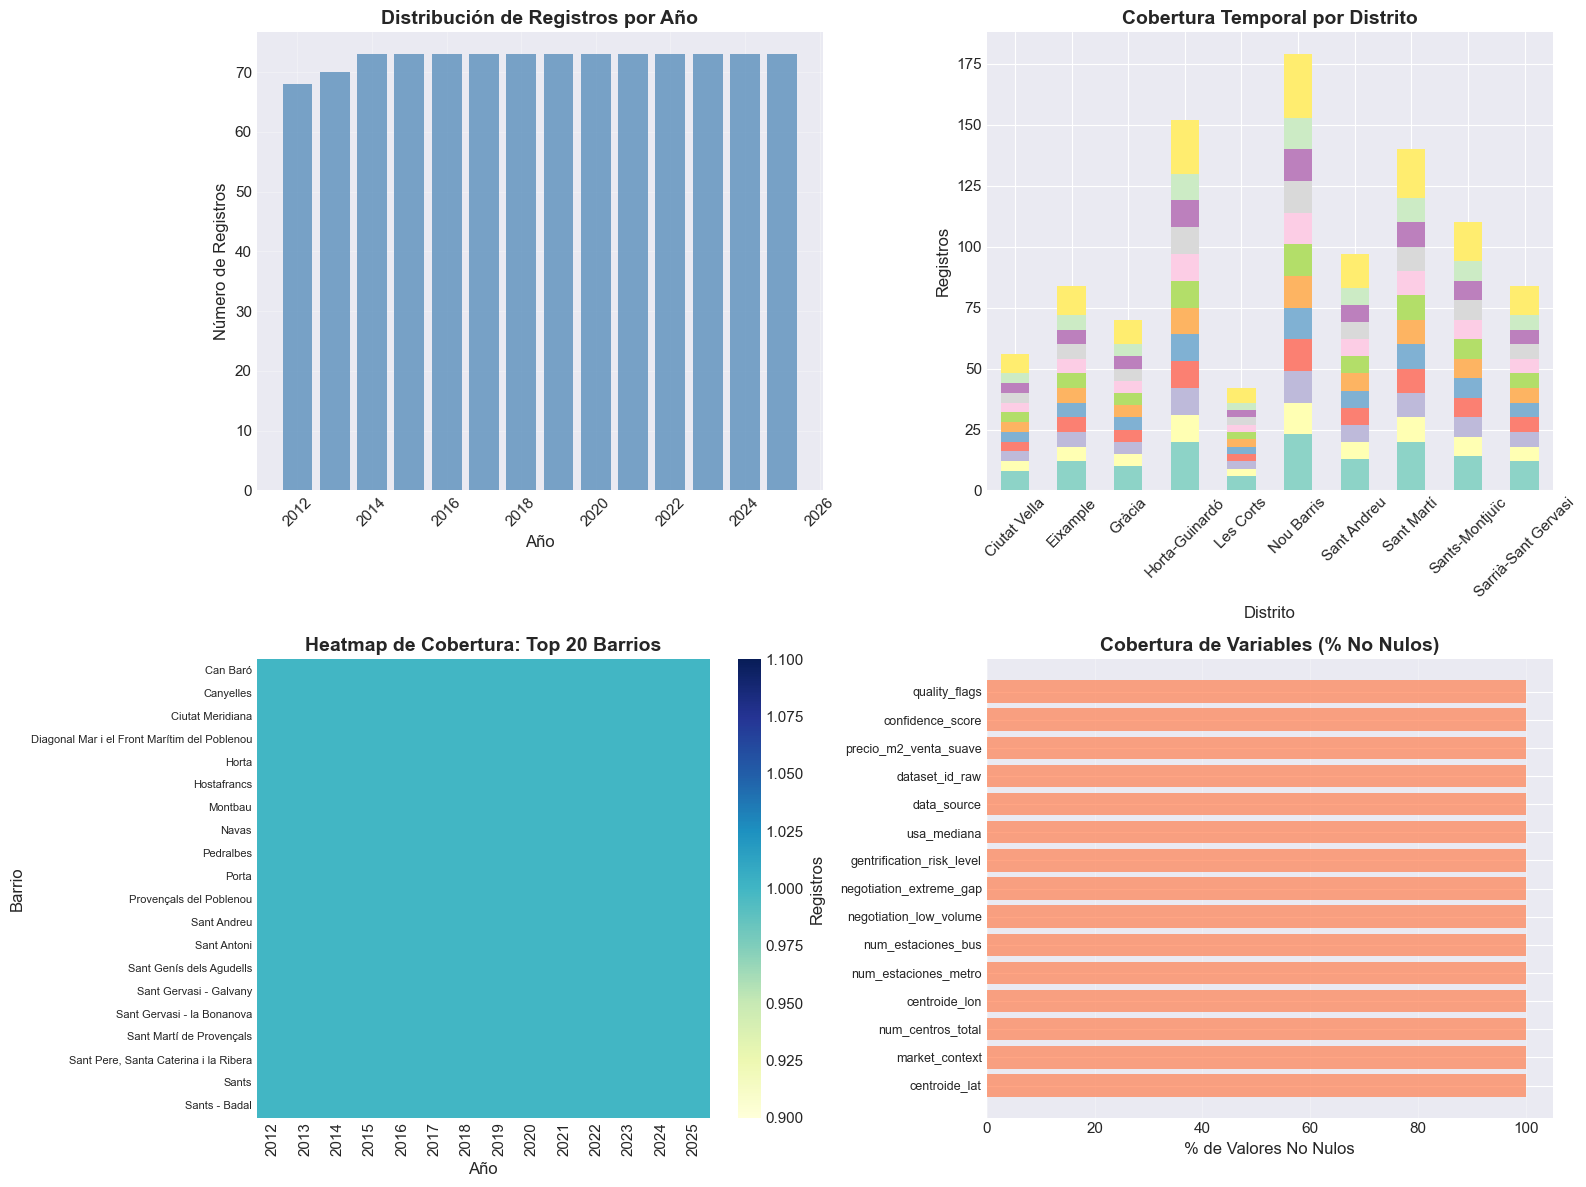


✅ Visualizaciones de cobertura completadas


In [4]:
# Visualización de cobertura temporal
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de años
year_counts = df['anio'].value_counts().sort_index()
axes[0, 0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.7)
axes[0, 0].set_title('Distribución de Registros por Año', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Número de Registros')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Cobertura temporal por distrito
distrito_coverage = df.groupby(['distrito_nombre', 'anio']).size().unstack(fill_value=0)
distrito_coverage.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set3', legend=False)
axes[0, 1].set_title('Cobertura Temporal por Distrito', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Distrito')
axes[0, 1].set_ylabel('Registros')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Heatmap de cobertura por barrio (muestra primeros 20)
top_barrios = df.groupby('barrio_nombre')['anio'].nunique().nlargest(20).index
coverage_matrix = df[df['barrio_nombre'].isin(top_barrios)].pivot_table(
    index='barrio_nombre', columns='anio', values='precio_m2_venta_promedio', 
    aggfunc='count', fill_value=0
)
sns.heatmap(coverage_matrix, annot=False, fmt='d', cmap='YlGnBu', ax=axes[1, 0], cbar_kws={'label': 'Registros'})
axes[1, 0].set_title('Heatmap de Cobertura: Top 20 Barrios', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Barrio')
axes[1, 0].tick_params(axis='y', labelsize=8)

# 4. Porcentaje de valores no nulos por variable
top_vars = coverage_df.head(15)
axes[1, 1].barh(range(len(top_vars)), top_vars['pct'].values, color='coral', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_vars)))
axes[1, 1].set_yticklabels(top_vars.index, fontsize=9)
axes[1, 1].set_title('Cobertura de Variables (% No Nulos)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('% de Valores No Nulos')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones de cobertura completadas")

## 2.5. Investigación de Anomalías y Valores Raros <a id='2-5-anomalias'></a>

In [5]:
# Investigación de anomalías y valores raros
print("=" * 80)
print("INVESTIGACIÓN DE ANOMALÍAS Y VALORES RAROS")
print("=" * 80)

# 1. Detectar cambios abruptos año a año
df_sorted = df.sort_values(['barrio_id', 'anio']).copy()
df_sorted['precio_change_pct'] = df_sorted.groupby('barrio_id')['precio_m2_venta_promedio'].pct_change(fill_method=None) * 100
df_sorted['alquiler_change_pct'] = df_sorted.groupby('barrio_id')['precio_mes_alquiler_promedio'].pct_change(fill_method=None) * 100

# Cambios abruptos (>50% o <-50%)
abrupt_venta = df_sorted[
    (df_sorted['precio_change_pct'].abs() > 50) & 
    df_sorted['precio_change_pct'].notna()
].copy()

abrupt_alquiler = df_sorted[
    (df_sorted['alquiler_change_pct'].abs() > 50) & 
    df_sorted['alquiler_change_pct'].notna()
].copy()

print(f"\n📊 Cambios abruptos detectados:")
print(f"   • Precio de venta: {len(abrupt_venta)} cambios >50%")
print(f"   • Precio de alquiler: {len(abrupt_alquiler)} cambios >50%")

if len(abrupt_venta) > 0:
    print(f"\n⚠️ Top 10 cambios más extremos en PRECIO DE VENTA:")
    top_abrupt = abrupt_venta.nlargest(10, 'precio_change_pct', keep='all')
    for idx, row in top_abrupt.iterrows():
        print(f"   {row['barrio_nombre']:30s} | {row['anio']:.0f} | "
              f"Cambio: {row['precio_change_pct']:+7.1f}% | "
              f"Precio: {row['precio_m2_venta_promedio']:,.0f} €/m²")

# 2. Identificar lagunas de datos (años faltantes)
print(f"\n📊 Análisis de lagunas de datos:")
all_years = sorted(df['anio'].unique())
barrios_with_gaps = []

for barrio_id in df['barrio_id'].unique():
    barrio_data = df[df['barrio_id'] == barrio_id].sort_values('anio')
    barrio_years = sorted(barrio_data['anio'].unique())
    missing_years = [y for y in all_years if y not in barrio_years]
    
    # Años con precios nulos
    null_price_years = barrio_data[
        barrio_data['precio_m2_venta_promedio'].isna()
    ]['anio'].tolist()
    
    if missing_years or null_price_years:
        barrios_with_gaps.append({
            'barrio_id': barrio_id,
            'barrio_nombre': barrio_data['barrio_nombre'].iloc[0],
            'missing_years': missing_years,
            'null_price_years': null_price_years,
            'total_gaps': len(missing_years) + len(null_price_years)
        })

if barrios_with_gaps:
    print(f"   ⚠️ {len(barrios_with_gaps)} barrios con lagunas de datos:")
    sorted_gaps = sorted(barrios_with_gaps, key=lambda x: x['total_gaps'], reverse=True)
    for gap_info in sorted_gaps[:10]:
        issues = []
        if gap_info['missing_years']:
            issues.append(f"{len(gap_info['missing_years'])} años faltantes")
        if gap_info['null_price_years']:
            issues.append(f"{len(gap_info['null_price_years'])} años con precios nulos")
        print(f"   • {gap_info['barrio_nombre']:30s}: {', '.join(issues)}")
else:
    print("   ✅ No se detectaron lagunas significativas")

# 3. Detectar outliers estadísticos (Z-score > 3)
print(f"\n📊 Detección de outliers estadísticos:")
df_outliers = df.copy()
df_outliers['z_score'] = np.nan

for year in df['anio'].unique():
    year_mask = df['anio'] == year
    year_prices = df.loc[year_mask, 'precio_m2_venta_promedio'].dropna()
    
    if len(year_prices) > 1:
        mean_price = year_prices.mean()
        std_price = year_prices.std()
        
        if std_price > 0:
            z_scores = (df.loc[year_mask, 'precio_m2_venta_promedio'] - mean_price) / std_price
            df_outliers.loc[year_mask, 'z_score'] = z_scores

outliers = df_outliers[
    (df_outliers['z_score'].abs() > 3) & 
    df_outliers['z_score'].notna()
].copy()

print(f"   • Outliers detectados (Z-score > 3): {len(outliers)}")
if len(outliers) > 0:
    print(f"\n   Top outliers:")
    top_outliers = outliers.nlargest(5, 'z_score', keep='all')
    for idx, row in top_outliers.iterrows():
        print(f"   • {row['barrio_nombre']:30s} | {row['anio']:.0f} | "
              f"Z-score: {row['z_score']:+6.2f} | "
              f"Precio: {row['precio_m2_venta_promedio']:,.0f} €/m²")

INVESTIGACIÓN DE ANOMALÍAS Y VALORES RAROS

📊 Cambios abruptos detectados:
   • Precio de venta: 16 cambios >50%
   • Precio de alquiler: 6 cambios >50%

⚠️ Top 10 cambios más extremos en PRECIO DE VENTA:
   Can Peguera                    | 2017 | Cambio:  +179.3% | Precio: 1,715 €/m²
   Torre Baró                     | 2019 | Cambio:  +174.7% | Precio: 2,070 €/m²
   la Marina del Prat Vermell     | 2015 | Cambio:  +135.0% | Precio: 1,436 €/m²
   Vallvidrera, el Tibidabo i les Planes | 2016 | Cambio:  +110.8% | Precio: 3,650 €/m²
   la Clota                       | 2019 | Cambio:   +99.4% | Precio: 2,912 €/m²
   la Marina del Prat Vermell     | 2020 | Cambio:   +71.1% | Precio: 1,910 €/m²
   Baró de Viver                  | 2017 | Cambio:   +70.1% | Precio: 1,124 €/m²
   el Barri Gòtic                 | 2016 | Cambio:   +61.8% | Precio: 4,138 €/m²
   Ciutat Meridiana               | 2015 | Cambio:   +60.2% | Precio: 1,347 €/m²
   Baró de Viver                  | 2020 | Cambio:   +55.6%

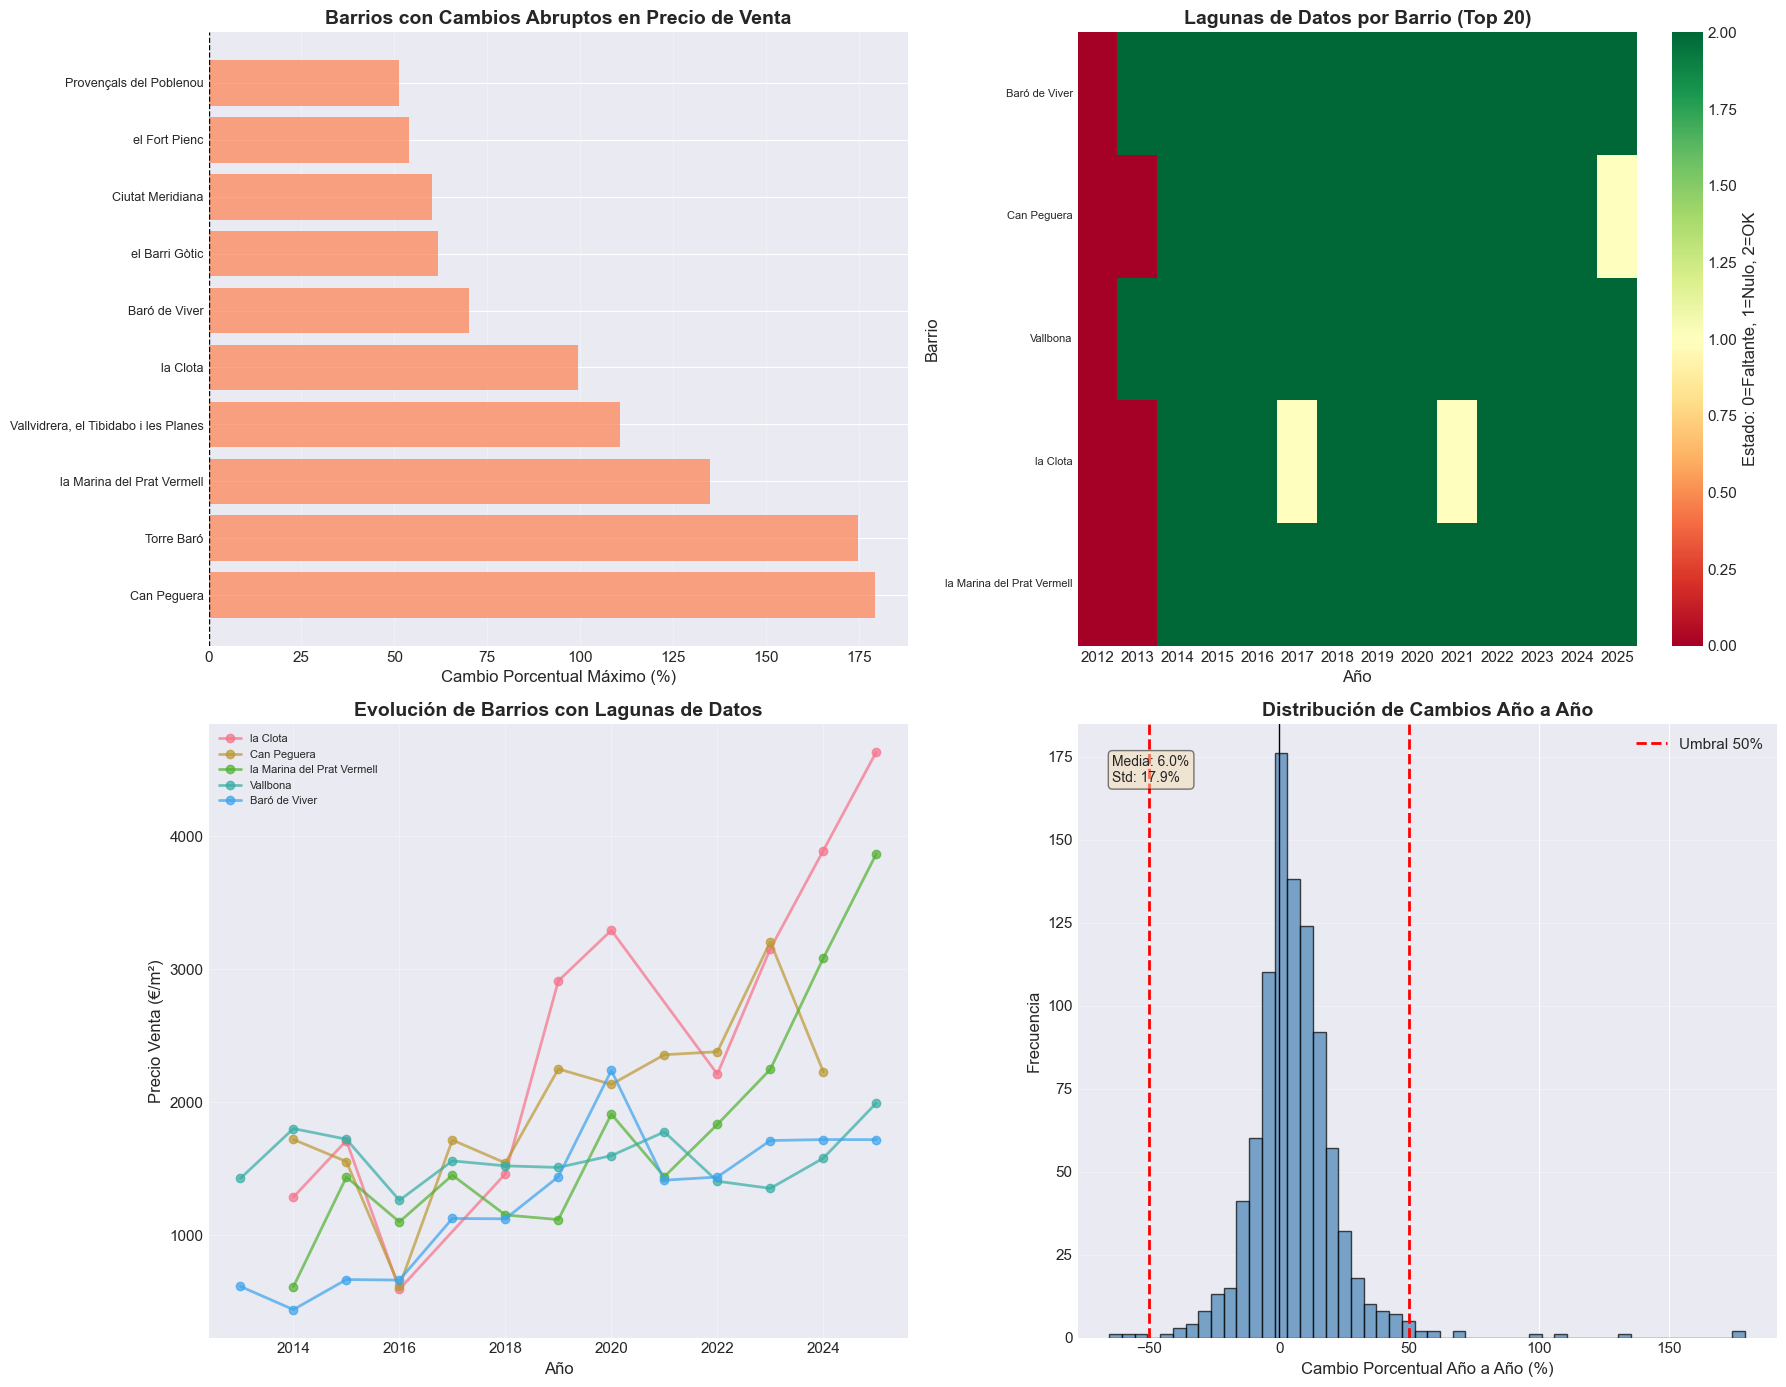


✅ Visualizaciones de anomalías completadas

💡 INTERPRETACIÓN:
   • Cambios abruptos >100% pueden indicar errores de datos o cambios reales muy significativos
   • Las lagunas (años faltantes) aparecen como 'caídas' en los gráficos pero son datos faltantes
   • Se recomienda investigar barrios con múltiples cambios abruptos o lagunas


In [6]:
# Visualización de anomalías
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Cambios abruptos en precios de venta
if len(abrupt_venta) > 0:
    # Agrupar por barrio y mostrar cambios
    abrupt_by_barrio = abrupt_venta.groupby('barrio_nombre').agg({
        'precio_change_pct': ['count', lambda x: x.abs().max()],
        'anio': 'first'
    }).reset_index()
    abrupt_by_barrio.columns = ['barrio_nombre', 'num_cambios', 'max_cambio', 'primer_anio']
    abrupt_by_barrio = abrupt_by_barrio.sort_values('max_cambio', ascending=False).head(15)
    
    colors = ['red' if x < 0 else 'green' for x in abrupt_venta[abrupt_venta['barrio_nombre'].isin(abrupt_by_barrio['barrio_nombre'])]['precio_change_pct']]
    
    axes[0, 0].barh(range(len(abrupt_by_barrio)), abrupt_by_barrio['max_cambio'].values,
                     color='coral', alpha=0.7)
    axes[0, 0].set_yticks(range(len(abrupt_by_barrio)))
    axes[0, 0].set_yticklabels(abrupt_by_barrio['barrio_nombre'], fontsize=9)
    axes[0, 0].set_xlabel('Cambio Porcentual Máximo (%)', fontsize=12)
    axes[0, 0].set_title('Barrios con Cambios Abruptos en Precio de Venta', fontsize=14, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].grid(True, alpha=0.3, axis='x')
else:
    axes[0, 0].text(0.5, 0.5, 'No se detectaron cambios abruptos', 
                    ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=14)
    axes[0, 0].set_title('Cambios Abruptos en Precio de Venta', fontsize=14, fontweight='bold')

# 2. Heatmap de lagunas de datos por barrio
if barrios_with_gaps:
    # Crear matriz de cobertura
    gap_matrix_data = []
    for gap_info in sorted_gaps[:20]:  # Top 20 barrios con más problemas
        barrio_id = gap_info['barrio_id']
        barrio_name = gap_info['barrio_nombre']
        barrio_data = df[df['barrio_id'] == barrio_id].sort_values('anio')
        
        for year in all_years:
            year_data = barrio_data[barrio_data['anio'] == year]
            if len(year_data) == 0:
                status = 0  # Año faltante
            elif year_data['precio_m2_venta_promedio'].isna().any():
                status = 1  # Precio nulo
            else:
                status = 2  # Datos disponibles
            
            gap_matrix_data.append({
                'barrio': barrio_name,
                'anio': year,
                'status': status
            })
    
    gap_matrix_df = pd.DataFrame(gap_matrix_data)
    gap_pivot = gap_matrix_df.pivot(index='barrio', columns='anio', values='status')
    
    sns.heatmap(gap_pivot, annot=False, fmt='d', cmap='RdYlGn', ax=axes[0, 1], 
                cbar_kws={'label': 'Estado: 0=Faltante, 1=Nulo, 2=OK'}, vmin=0, vmax=2)
    axes[0, 1].set_title('Lagunas de Datos por Barrio (Top 20)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Año')
    axes[0, 1].set_ylabel('Barrio')
    axes[0, 1].tick_params(axis='y', labelsize=8)
else:
    axes[0, 1].text(0.5, 0.5, 'No se detectaron lagunas significativas', 
                    ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=14)
    axes[0, 1].set_title('Lagunas de Datos', fontsize=14, fontweight='bold')

# 3. Evolución temporal de barrios problemáticos
if barrios_with_gaps:
    problem_barrios = [g['barrio_nombre'] for g in sorted_gaps[:5]]
    
    for barrio_name in problem_barrios:
        barrio_data = df[df['barrio_nombre'] == barrio_name].sort_values('anio')
        barrio_data_valid = barrio_data[barrio_data['precio_m2_venta_promedio'].notna()]
        
        if len(barrio_data_valid) > 0:
            axes[1, 0].plot(barrio_data_valid['anio'], barrio_data_valid['precio_m2_venta_promedio'],
                           'o-', linewidth=2, markersize=6, label=barrio_name, alpha=0.7)
    
    axes[1, 0].set_xlabel('Año', fontsize=12)
    axes[1, 0].set_ylabel('Precio Venta (€/m²)', fontsize=12)
    axes[1, 0].set_title('Evolución de Barrios con Lagunas de Datos', fontsize=14, fontweight='bold')
    axes[1, 0].legend(loc='best', fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No hay barrios problemáticos', 
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=14)
    axes[1, 0].set_title('Barrios con Lagunas', fontsize=14, fontweight='bold')

# 4. Distribución de cambios año a año
if len(df_sorted) > 0:
    cambios_validos = df_sorted[df_sorted['precio_change_pct'].notna()]['precio_change_pct']
    
    axes[1, 1].hist(cambios_validos, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Umbral 50%')
    axes[1, 1].axvline(x=-50, color='red', linestyle='--', linewidth=2)
    axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 1].set_xlabel('Cambio Porcentual Año a Año (%)', fontsize=12)
    axes[1, 1].set_ylabel('Frecuencia', fontsize=12)
    axes[1, 1].set_title('Distribución de Cambios Año a Año', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Estadísticas
    mean_change = cambios_validos.mean()
    std_change = cambios_validos.std()
    axes[1, 1].text(0.05, 0.95, f'Media: {mean_change:.1f}%\nStd: {std_change:.1f}%', 
                    transform=axes[1, 1].transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones de anomalías completadas")
print("\n💡 INTERPRETACIÓN:")
print("   • Cambios abruptos >100% pueden indicar errores de datos o cambios reales muy significativos")
print("   • Las lagunas (años faltantes) aparecen como 'caídas' en los gráficos pero son datos faltantes")
print("   • Se recomienda investigar barrios con múltiples cambios abruptos o lagunas")

## 3. Análisis de Cambios Significativos <a id='3-cambios'></a>

In [7]:
# Identificar cambios significativos en variables clave
print("=" * 80)
print("ANÁLISIS DE CAMBIOS SIGNIFICATIVOS")
print("=" * 80)

# Variables numéricas clave para análisis de cambios
key_variables = [
    'precio_m2_venta_promedio',
    'precio_mes_alquiler_promedio',
    'poblacion_total',
    'densidad_poblacion',
    'total_establecimientos_turisticos',
    'tasa_criminalidad_promedio',
    'total_delitos'
]

def calculate_change_metrics(df, var_name):
    """Calcula métricas de cambio para una variable."""
    changes = []
    for barrio_id in df['barrio_id'].unique():
        barrio_data = df[df['barrio_id'] == barrio_id].sort_values('anio')
        if len(barrio_data) < 2:
            continue
            
        values = barrio_data[var_name].dropna()
        if len(values) < 2:
            continue
            
        first_val = values.iloc[0]
        last_val = values.iloc[-1]
        first_year = barrio_data[barrio_data[var_name].notna()]['anio'].iloc[0]
        last_year = barrio_data[barrio_data[var_name].notna()]['anio'].iloc[-1]
        
        if pd.notna(first_val) and pd.notna(last_val) and first_val != 0:
            pct_change = ((last_val - first_val) / first_val) * 100
            abs_change = last_val - first_val
            years_span = last_year - first_year
            annual_change = pct_change / years_span if years_span > 0 else 0
            
            changes.append({
                'barrio_id': barrio_id,
                'barrio_nombre': barrio_data['barrio_nombre'].iloc[0],
                'distrito_nombre': barrio_data['distrito_nombre'].iloc[0],
                'variable': var_name,
                'valor_inicial': first_val,
                'valor_final': last_val,
                'cambio_absoluto': abs_change,
                'cambio_porcentual': pct_change,
                'cambio_anual_pct': annual_change,
                'anio_inicial': first_year,
                'anio_final': last_year,
                'span_anios': years_span
            })
    
    return pd.DataFrame(changes)

# Calcular cambios para todas las variables clave
all_changes = []
for var in key_variables:
    if var in df.columns:
        changes_df = calculate_change_metrics(df, var)
        if len(changes_df) > 0:
            all_changes.append(changes_df)

if len(all_changes) > 0:
    changes_summary = pd.concat(all_changes, ignore_index=True)
    
    print(f"\n📊 Total de cambios calculados: {len(changes_summary)}")
    print(f"   Variables analizadas: {changes_summary['variable'].nunique()}")
    
    # Identificar cambios más significativos (top 5 por variable)
    print("\n🔍 TOP 5 CAMBIOS MÁS SIGNIFICATIVOS (por cambio porcentual):")
    for var in key_variables:
        if var in changes_summary['variable'].values:
            var_changes = changes_summary[changes_summary['variable'] == var].copy()
            var_changes['abs_change_pct'] = var_changes['cambio_porcentual'].abs()
            top_changes = var_changes.nlargest(5, 'abs_change_pct')
            
            if len(top_changes) > 0:
                print(f"\n📈 {var}:")
                print(top_changes[['barrio_nombre', 'distrito_nombre', 'cambio_porcentual', 
                                   'cambio_anual_pct', 'anio_inicial', 'anio_final']].to_string(index=False))
else:
    print("⚠️ No se pudieron calcular cambios significativos")

ANÁLISIS DE CAMBIOS SIGNIFICATIVOS

📊 Total de cambios calculados: 278
   Variables analizadas: 4

🔍 TOP 5 CAMBIOS MÁS SIGNIFICATIVOS (por cambio porcentual):

📈 precio_m2_venta_promedio:
             barrio_nombre distrito_nombre  cambio_porcentual  cambio_anual_pct  anio_inicial  anio_final
la Marina del Prat Vermell  Sants-Montjuïc             532.83             48.44          2014        2025
                  la Clota  Horta-Guinardó             260.67             23.70          2014        2025
             Baró de Viver     Sant Andreu             180.11             15.01          2013        2025
         la Vila de Gràcia          Gràcia             128.29              9.87          2012        2025
         la Marina de Port  Sants-Montjuïc             119.42              9.19          2012        2025

📈 precio_mes_alquiler_promedio:
             barrio_nombre distrito_nombre  cambio_porcentual  cambio_anual_pct  anio_inicial  anio_final
la Marina del Prat Vermell  Sants-Mon

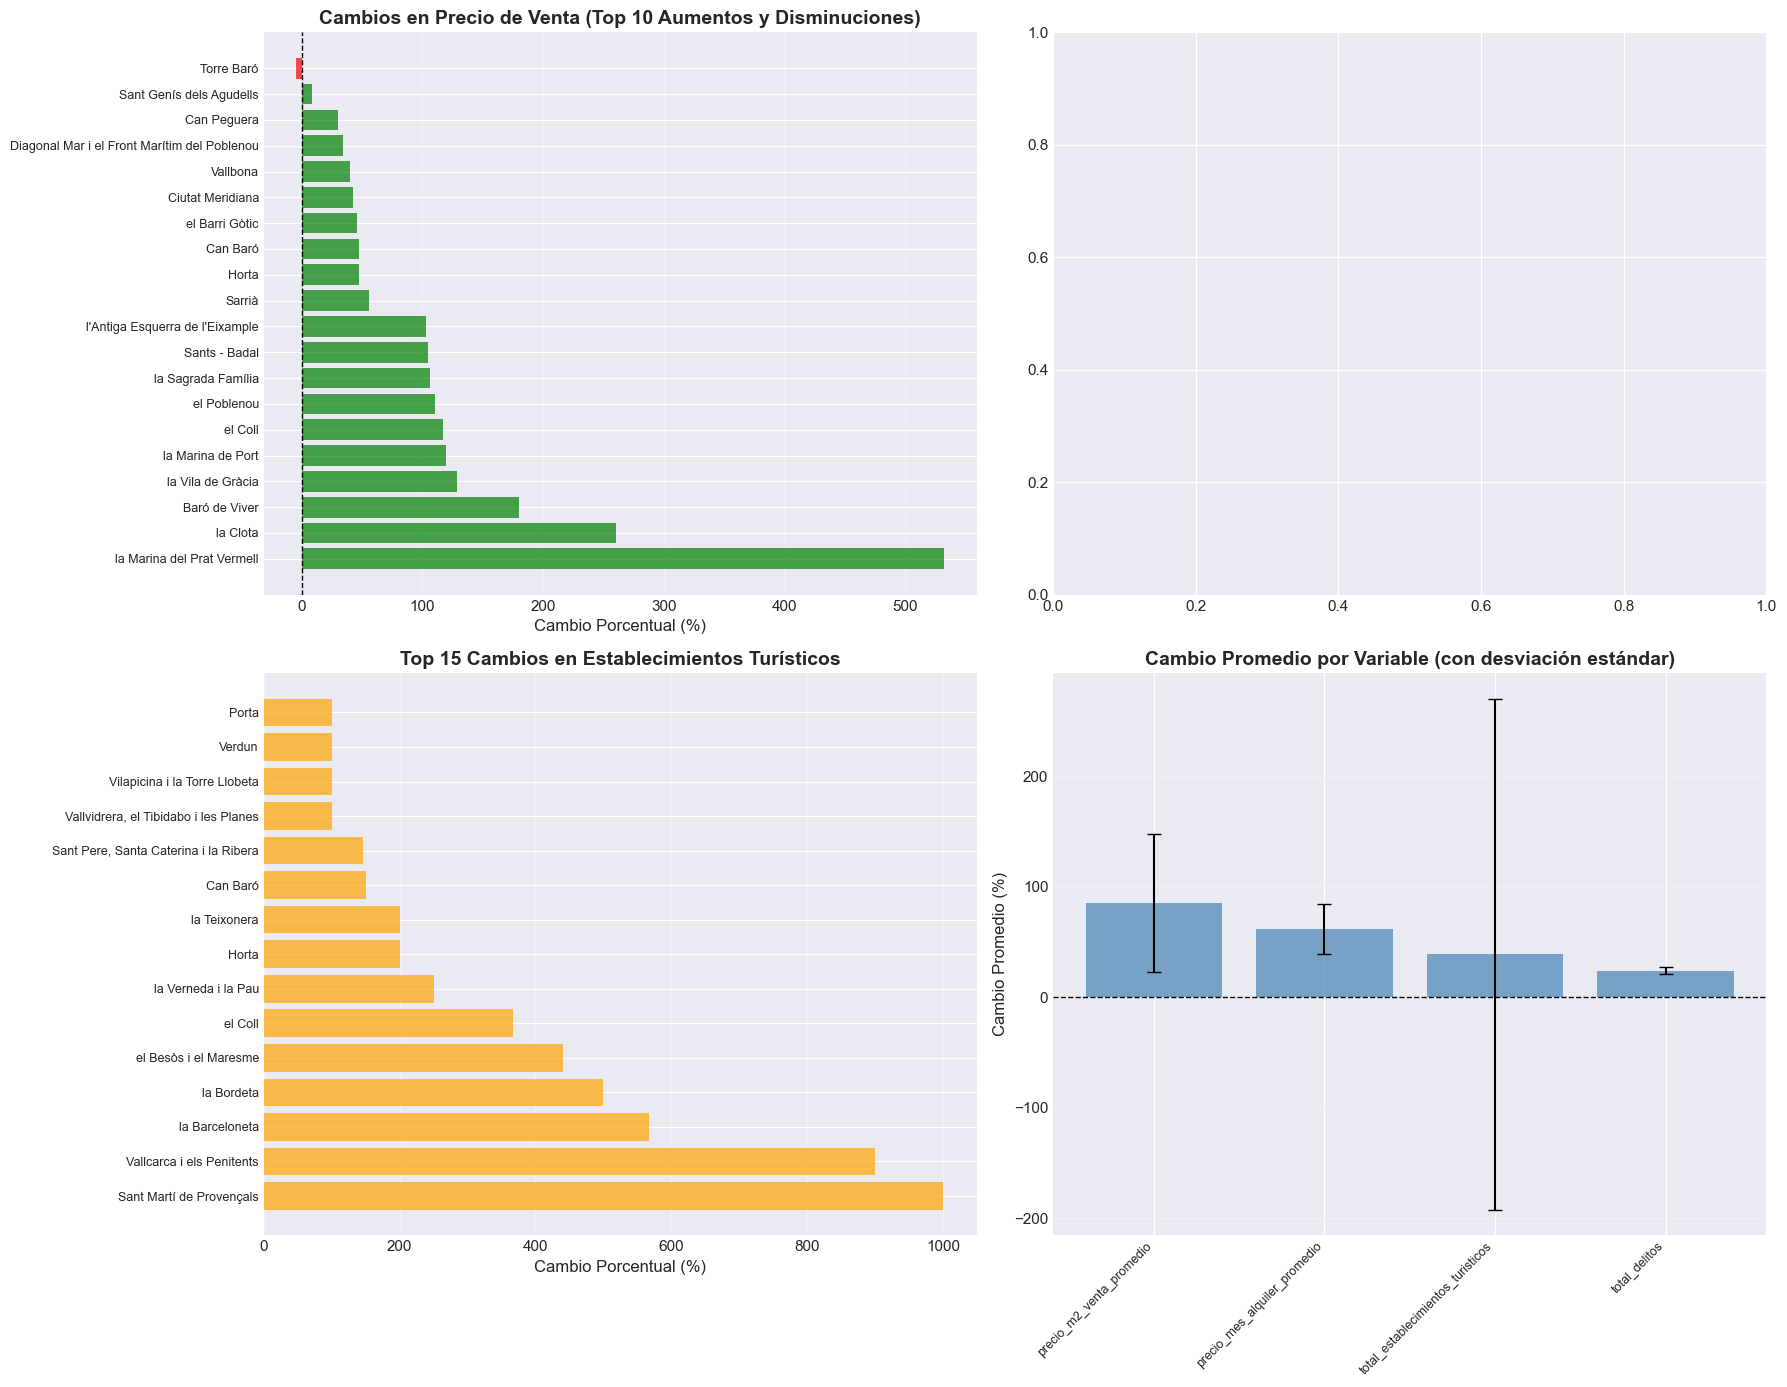


✅ Visualizaciones de cambios completadas


In [8]:
# Visualización de cambios significativos
if len(all_changes) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 1. Cambios en precio de venta
    precio_changes = changes_summary[changes_summary['variable'] == 'precio_m2_venta_promedio'].copy()
    precio_changes = precio_changes.sort_values('cambio_porcentual', ascending=False)
    
    top_increase = precio_changes.head(10)
    top_decrease = precio_changes.tail(10)
    
    combined = pd.concat([top_increase, top_decrease])
    colors = ['green' if x > 0 else 'red' for x in combined['cambio_porcentual']]
    
    axes[0, 0].barh(range(len(combined)), combined['cambio_porcentual'].values, 
                     color=colors, alpha=0.7)
    axes[0, 0].set_yticks(range(len(combined)))
    axes[0, 0].set_yticklabels(combined['barrio_nombre'], fontsize=9)
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Cambios en Precio de Venta (Top 10 Aumentos y Disminuciones)', 
                         fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Cambio Porcentual (%)')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # 2. Cambios en población
    if 'poblacion_total' in changes_summary['variable'].values:
        poblacion_changes = changes_summary[changes_summary['variable'] == 'poblacion_total'].copy()
        poblacion_changes = poblacion_changes.sort_values('cambio_porcentual', ascending=False)
        
        axes[0, 1].scatter(poblacion_changes['cambio_porcentual'], 
                            poblacion_changes['cambio_anual_pct'],
                            s=100, alpha=0.6, c=range(len(poblacion_changes)),
                            cmap='tab20')
        axes[0, 1].set_title('Cambios en Población: Total vs Anual', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Cambio Total (%)')
        axes[0, 1].set_ylabel('Cambio Anual Promedio (%)')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
        axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    # 3. Cambios en turismo
    if 'total_establecimientos_turisticos' in changes_summary['variable'].values:
        turismo_changes = changes_summary[changes_summary['variable'] == 'total_establecimientos_turisticos'].copy()
        turismo_changes = turismo_changes.sort_values('cambio_porcentual', ascending=False).head(15)
        
        axes[1, 0].barh(range(len(turismo_changes)), turismo_changes['cambio_porcentual'].values,
                         color='orange', alpha=0.7)
        axes[1, 0].set_yticks(range(len(turismo_changes)))
        axes[1, 0].set_yticklabels(turismo_changes['barrio_nombre'], fontsize=9)
        axes[1, 0].set_title('Top 15 Cambios en Establecimientos Turísticos', 
                             fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Cambio Porcentual (%)')
        axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # 4. Distribución de cambios por variable
    change_dist = changes_summary.groupby('variable')['cambio_porcentual'].agg(['mean', 'std', 'min', 'max']).reset_index()
    change_dist = change_dist.sort_values('mean', ascending=False)
    
    x_pos = np.arange(len(change_dist))
    axes[1, 1].bar(x_pos, change_dist['mean'].values, yerr=change_dist['std'].values,
                   alpha=0.7, color='steelblue', capsize=5)
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(change_dist['variable'], rotation=45, ha='right', fontsize=9)
    axes[1, 1].set_title('Cambio Promedio por Variable (con desviación estándar)', 
                         fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Cambio Promedio (%)')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Visualizaciones de cambios completadas")
else:
    print("⚠️ No hay datos para visualizar cambios")

## 4. Análisis de Correlaciones <a id='4-correlaciones'></a>

In [9]:
# Análisis de correlaciones con precios
print("=" * 80)
print("ANÁLISIS DE CORRELACIONES CON PRECIOS")
print("=" * 80)

# Seleccionar variables numéricas para correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir IDs y años
exclude_cols = ['barrio_id', 'anio', 'ruido_anio']
correlation_vars = [col for col in numeric_cols if col not in exclude_cols]

# Calcular matriz de correlación
corr_matrix = df[correlation_vars].corr()

# Correlaciones con precio de venta
if 'precio_m2_venta_promedio' in corr_matrix.columns:
    precio_venta_corr = corr_matrix['precio_m2_venta_promedio'].sort_values(ascending=False)
    print("\n📊 CORRELACIONES CON PRECIO DE VENTA (m²):")
    print("=" * 80)
    for var, corr_val in precio_venta_corr.items():
        if var != 'precio_m2_venta_promedio' and pd.notna(corr_val):
            strength = "Muy fuerte" if abs(corr_val) > 0.7 else "Fuerte" if abs(corr_val) > 0.5 else "Moderada" if abs(corr_val) > 0.3 else "Débil"
            direction = "positiva" if corr_val > 0 else "negativa"
            print(f"  {var:40s}: {corr_val:7.3f} ({strength} {direction})")

# Correlaciones con precio de alquiler
if 'precio_mes_alquiler_promedio' in corr_matrix.columns:
    precio_alquiler_corr = corr_matrix['precio_mes_alquiler_promedio'].sort_values(ascending=False)
    print("\n📊 CORRELACIONES CON PRECIO DE ALQUILER (mes):")
    print("=" * 80)
    for var, corr_val in precio_alquiler_corr.items():
        if var != 'precio_mes_alquiler_promedio' and pd.notna(corr_val):
            strength = "Muy fuerte" if abs(corr_val) > 0.7 else "Fuerte" if abs(corr_val) > 0.5 else "Moderada" if abs(corr_val) > 0.3 else "Débil"
            direction = "positiva" if corr_val > 0 else "negativa"
            print(f"  {var:40s}: {corr_val:7.3f} ({strength} {direction})")

# Correlación entre venta y alquiler
if 'precio_m2_venta_promedio' in df.columns and 'precio_mes_alquiler_promedio' in df.columns:
    venta_alquiler_corr = df[['precio_m2_venta_promedio', 'precio_mes_alquiler_promedio']].corr().iloc[0, 1]
    print(f"\n🔗 Correlación Venta ↔ Alquiler: {venta_alquiler_corr:.3f}")

ANÁLISIS DE CORRELACIONES CON PRECIOS

📊 CORRELACIONES CON PRECIO DE VENTA (m²):
  precio_m2_venta_suave                   :   0.984 (Muy fuerte positiva)
  transaction_price_m2                    :   0.972 (Muy fuerte positiva)
  asking_price_m2                         :   0.952 (Muy fuerte positiva)
  precio_alquiler_suave                   :   0.894 (Muy fuerte positiva)
  precio_mes_alquiler_promedio            :   0.873 (Muy fuerte positiva)
  z_score_precio_venta                    :   0.863 (Muy fuerte positiva)
  precio_alquiler_prev_2y                 :   0.859 (Muy fuerte positiva)
  renta_bruta_llar                        :   0.765 (Muy fuerte positiva)
  indice_gini                             :   0.754 (Muy fuerte positiva)
  renta_promedio                          :   0.706 (Muy fuerte positiva)
  renta_euros                             :   0.706 (Muy fuerte positiva)
  renta_mediana                           :   0.694 (Fuerte positiva)
  anios_renta_para_comprar_70m2    

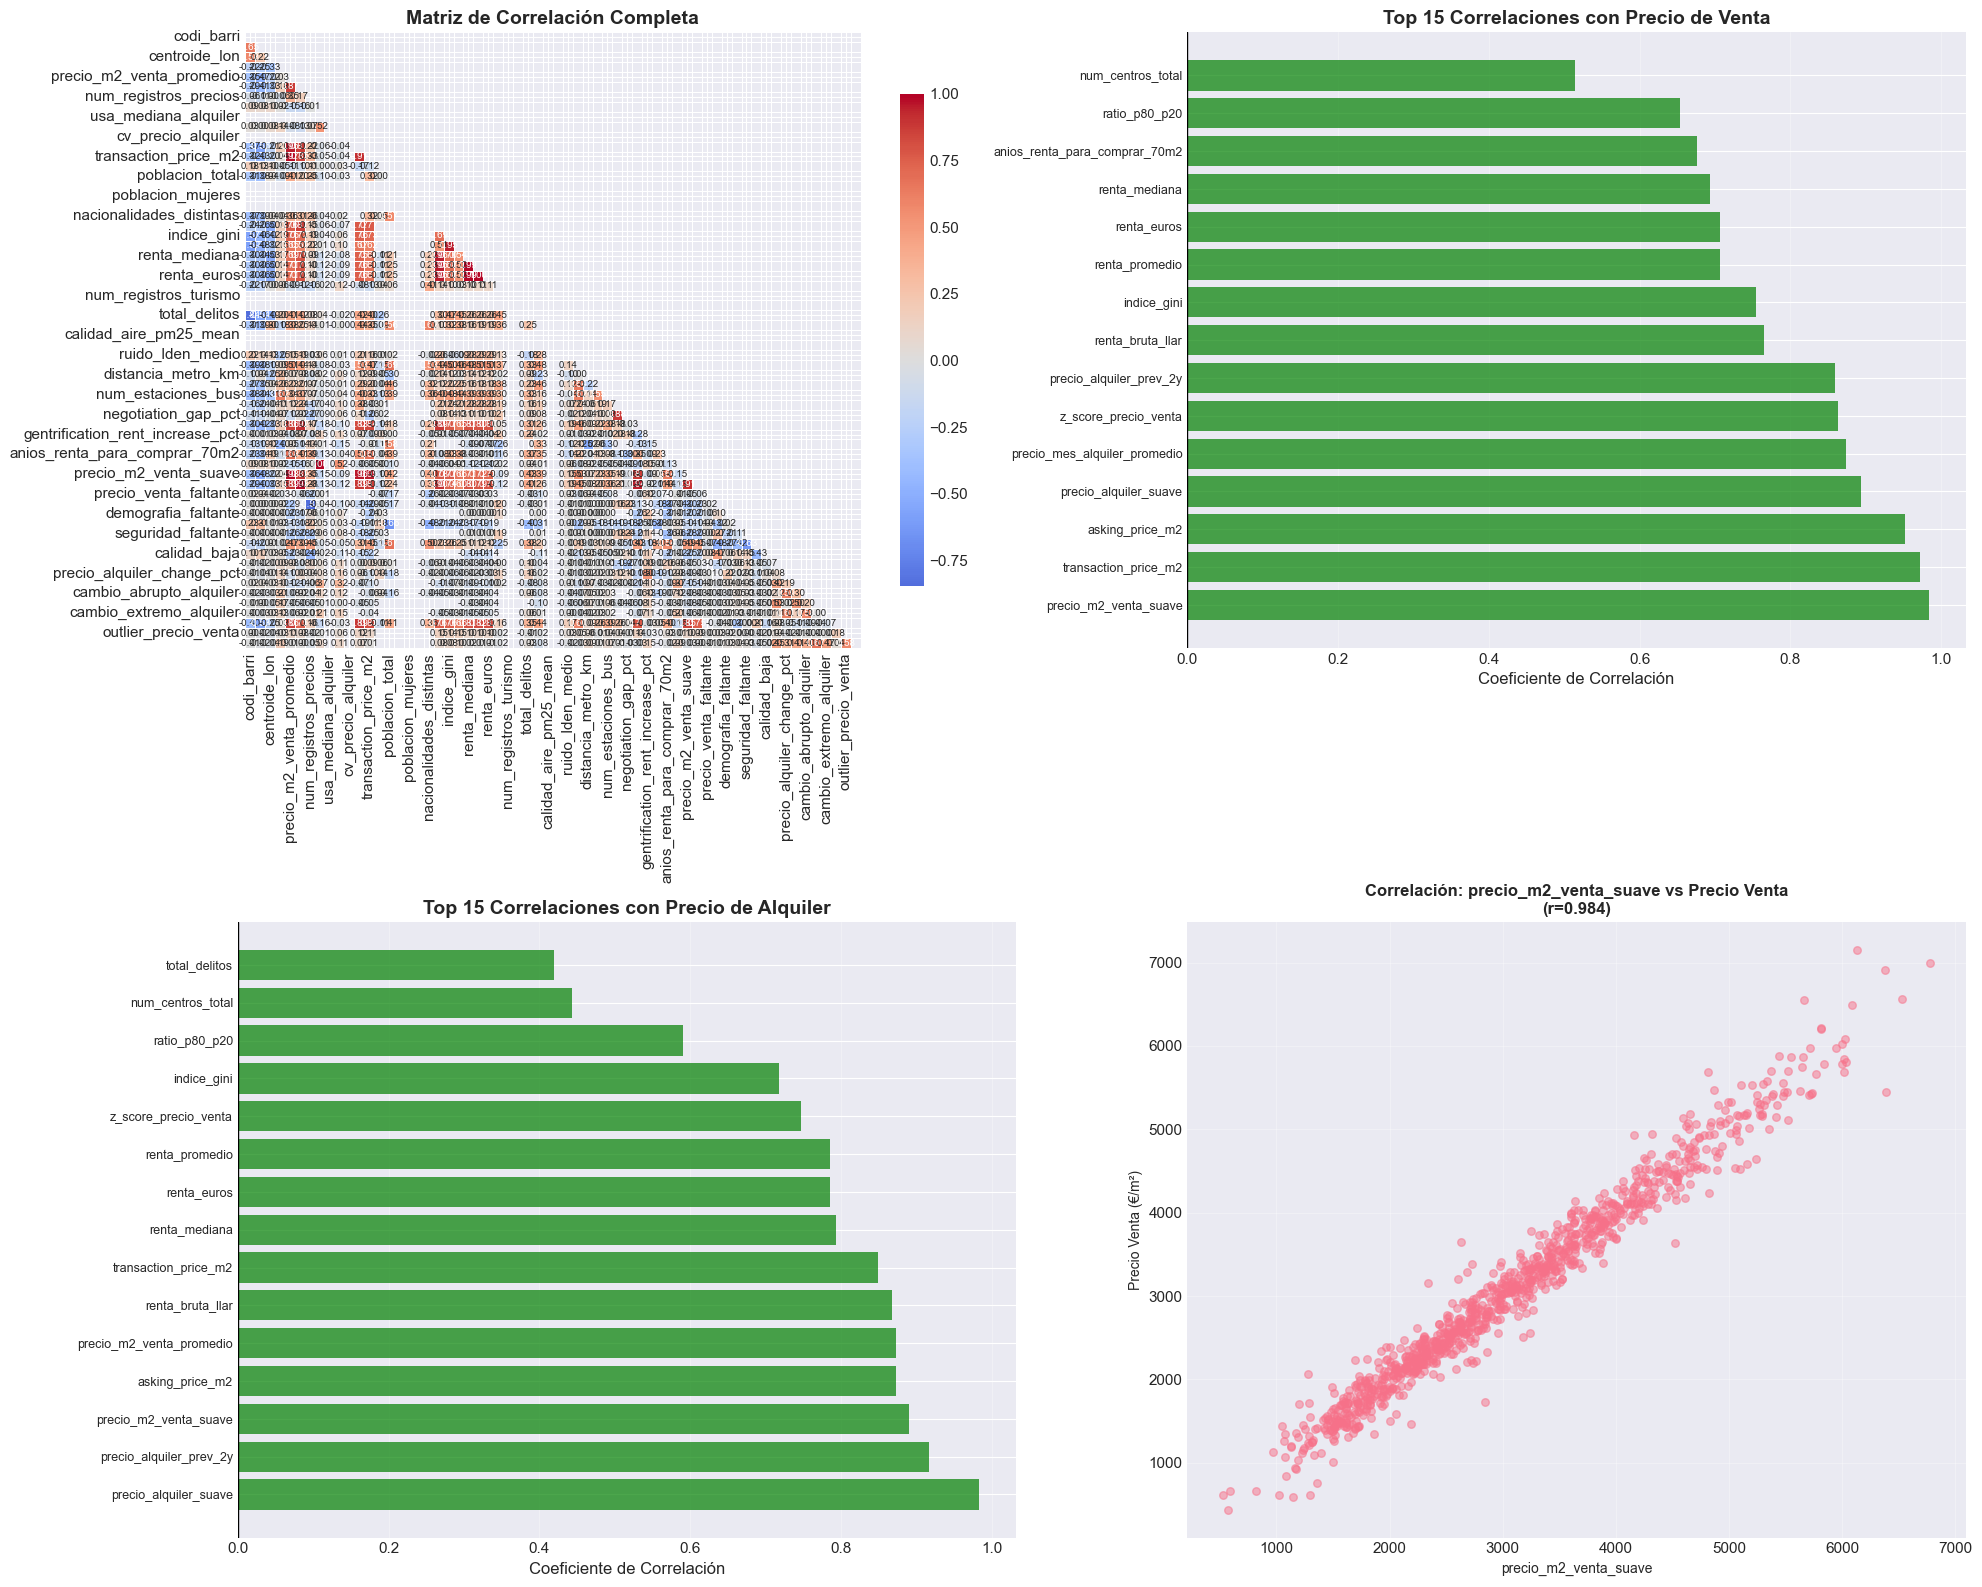


✅ Visualizaciones de correlaciones completadas


In [10]:
# Visualización de correlaciones
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Heatmap de correlación completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=axes[0, 0], annot_kws={'size': 7})
axes[0, 0].set_title('Matriz de Correlación Completa', fontsize=14, fontweight='bold')

# 2. Top correlaciones con precio de venta
if 'precio_m2_venta_promedio' in precio_venta_corr.index:
    top_corr_venta = precio_venta_corr.drop('precio_m2_venta_promedio').abs().nlargest(15)
    colors_venta = ['green' if precio_venta_corr[var] > 0 else 'red' for var in top_corr_venta.index]
    axes[0, 1].barh(range(len(top_corr_venta)), precio_venta_corr[top_corr_venta.index].values,
                     color=colors_venta, alpha=0.7)
    axes[0, 1].set_yticks(range(len(top_corr_venta)))
    axes[0, 1].set_yticklabels(top_corr_venta.index, fontsize=9)
    axes[0, 1].set_title('Top 15 Correlaciones con Precio de Venta', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Coeficiente de Correlación')
    axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Top correlaciones con precio de alquiler
if 'precio_mes_alquiler_promedio' in precio_alquiler_corr.index:
    top_corr_alquiler = precio_alquiler_corr.drop('precio_mes_alquiler_promedio').abs().nlargest(15)
    colors_alquiler = ['green' if precio_alquiler_corr[var] > 0 else 'red' for var in top_corr_alquiler.index]
    axes[1, 0].barh(range(len(top_corr_alquiler)), precio_alquiler_corr[top_corr_alquiler.index].values,
                     color=colors_alquiler, alpha=0.7)
    axes[1, 0].set_yticks(range(len(top_corr_alquiler)))
    axes[1, 0].set_yticklabels(top_corr_alquiler.index, fontsize=9)
    axes[1, 0].set_title('Top 15 Correlaciones con Precio de Alquiler', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Coeficiente de Correlación')
    axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Scatter plots de correlaciones más fuertes
if 'precio_m2_venta_promedio' in df.columns:
    # Seleccionar las 4 variables más correlacionadas (excluyendo el mismo precio)
    top_vars = precio_venta_corr.drop('precio_m2_venta_promedio').abs().nlargest(4).index
    
    for idx, var in enumerate(top_vars[:4]):
        if idx == 0:
            scatter_ax = axes[1, 1]
            scatter_ax.scatter(df[var], df['precio_m2_venta_promedio'], 
                             alpha=0.5, s=30)
            scatter_ax.set_xlabel(var, fontsize=10)
            scatter_ax.set_ylabel('Precio Venta (€/m²)', fontsize=10)
            scatter_ax.set_title(f'Correlación: {var} vs Precio Venta\n(r={precio_venta_corr[var]:.3f})', 
                                fontsize=12, fontweight='bold')
            scatter_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones de correlaciones completadas")

## 5. Líneas Temporales Multi-Variable <a id='5-timelines'></a>

In [11]:
# Crear líneas temporales con múltiples variables
print("=" * 80)
print("LÍNEAS TEMPORALES MULTI-VARIABLE")
print("=" * 80)

# Agregar datos a nivel de ciudad (promedio por año)
city_timeline = df.groupby('anio').agg({
    'precio_m2_venta_promedio': 'mean',
    'precio_mes_alquiler_promedio': 'mean',
    'poblacion_total': 'sum',
    'densidad_poblacion': 'mean',
    'total_establecimientos_turisticos': 'sum',
    'tasa_criminalidad_promedio': 'mean',
    'total_delitos': 'sum'
}).reset_index()

print("\n📊 Evolución temporal a nivel de ciudad:")
print(city_timeline.describe())

# Analizar calidad de datos por variable
print("\n⚠️ ANÁLISIS DE CALIDAD DE DATOS:")
print("=" * 80)
for col in city_timeline.columns:
    if col != 'anio':
        non_zero = (city_timeline[col] != 0).sum()
        non_null = city_timeline[col].notna().sum()
        total = len(city_timeline)
        pct_valid = (non_zero / total) * 100 if non_zero > 0 else 0
        
        # Identificar si los ceros son datos faltantes o valores reales
        if col in ['poblacion_total', 'total_delitos', 'total_establecimientos_turisticos']:
            # Para estas variables, 0 probablemente significa datos faltantes
            print(f"\n{col}:")
            print(f"  Años con datos válidos (>0): {non_zero}/{total} ({pct_valid:.1f}%)")
            if non_zero > 0:
                years_with_data = city_timeline[city_timeline[col] > 0]['anio'].tolist()
                print(f"  Años con datos: {years_with_data}")
        elif col == 'tasa_criminalidad_promedio':
            # Si todos son 0, probablemente datos no disponibles
            if (city_timeline[col] == 0).all():
                print(f"\n{col}:")
                print(f"  ⚠️ Todos los valores son 0 - datos no disponibles")
        elif col == 'densidad_poblacion':
            # Si solo hay 1 valor único, datos limitados
            unique_vals = city_timeline[col].nunique()
            if unique_vals <= 2:
                print(f"\n{col}:")
                print(f"  ⚠️ Solo {unique_vals} valor(es) único(s) - datos muy limitados")

# Filtrar variables con datos suficientes para visualización
# Variables con al menos 3 años de datos válidos
valid_vars = []
for col in ['precio_m2_venta_promedio', 'precio_mes_alquiler_promedio', 
            'poblacion_total', 'densidad_poblacion', 'total_establecimientos_turisticos', 
            'tasa_criminalidad_promedio', 'total_delitos']:
    if col in city_timeline.columns:
        # Para variables que pueden ser 0, contar solo valores > 0
        if col in ['poblacion_total', 'total_delitos', 'total_establecimientos_turisticos']:
            valid_count = (city_timeline[col] > 0).sum()
        else:
            valid_count = city_timeline[col].notna().sum()
        
        if valid_count >= 3:  # Mínimo 3 años de datos
            valid_vars.append(col)
            print(f"\n✅ {col}: {valid_count} años con datos válidos")

print(f"\n📋 Variables seleccionadas para visualización: {valid_vars}")

# Normalizar variables para visualización en la misma escala (solo variables válidas)
from sklearn.preprocessing import MinMaxScaler

# Crear instancia del scaler
scaler = MinMaxScaler()

timeline_vars = [v for v in ['precio_m2_venta_promedio', 'precio_mes_alquiler_promedio', 
                             'poblacion_total', 'total_establecimientos_turisticos', 
                             'tasa_criminalidad_promedio'] if v in valid_vars]

if len(timeline_vars) > 0:
    timeline_normalized = city_timeline[['anio'] + timeline_vars].copy()
    # Filtrar filas donde todas las variables son válidas para normalización
    mask = timeline_normalized[timeline_vars].notna().all(axis=1)
    if mask.sum() > 0:
        timeline_normalized.loc[mask, timeline_vars] = scaler.fit_transform(
            timeline_normalized.loc[mask, timeline_vars]
        )
else:
    timeline_normalized = city_timeline[['anio']].copy()

LÍNEAS TEMPORALES MULTI-VARIABLE

📊 Evolución temporal a nivel de ciudad:
         anio  precio_m2_venta_promedio  precio_mes_alquiler_promedio  \
count   14.00                     14.00                         12.00   
mean  2018.50                   3072.16                        861.31   
std      4.18                    605.92                        142.68   
min   2012.00                   2160.03                        629.52   
25%   2015.25                   2471.85                        778.41   
50%   2018.50                   3317.82                        863.63   
75%   2021.75                   3438.59                        953.70   
max   2025.00                   4052.83                       1073.13   

       poblacion_total  densidad_poblacion  total_establecimientos_turisticos  \
count            14.00                1.00                              14.00   
mean         104195.93            22648.53                             634.79   
std          389865.47   

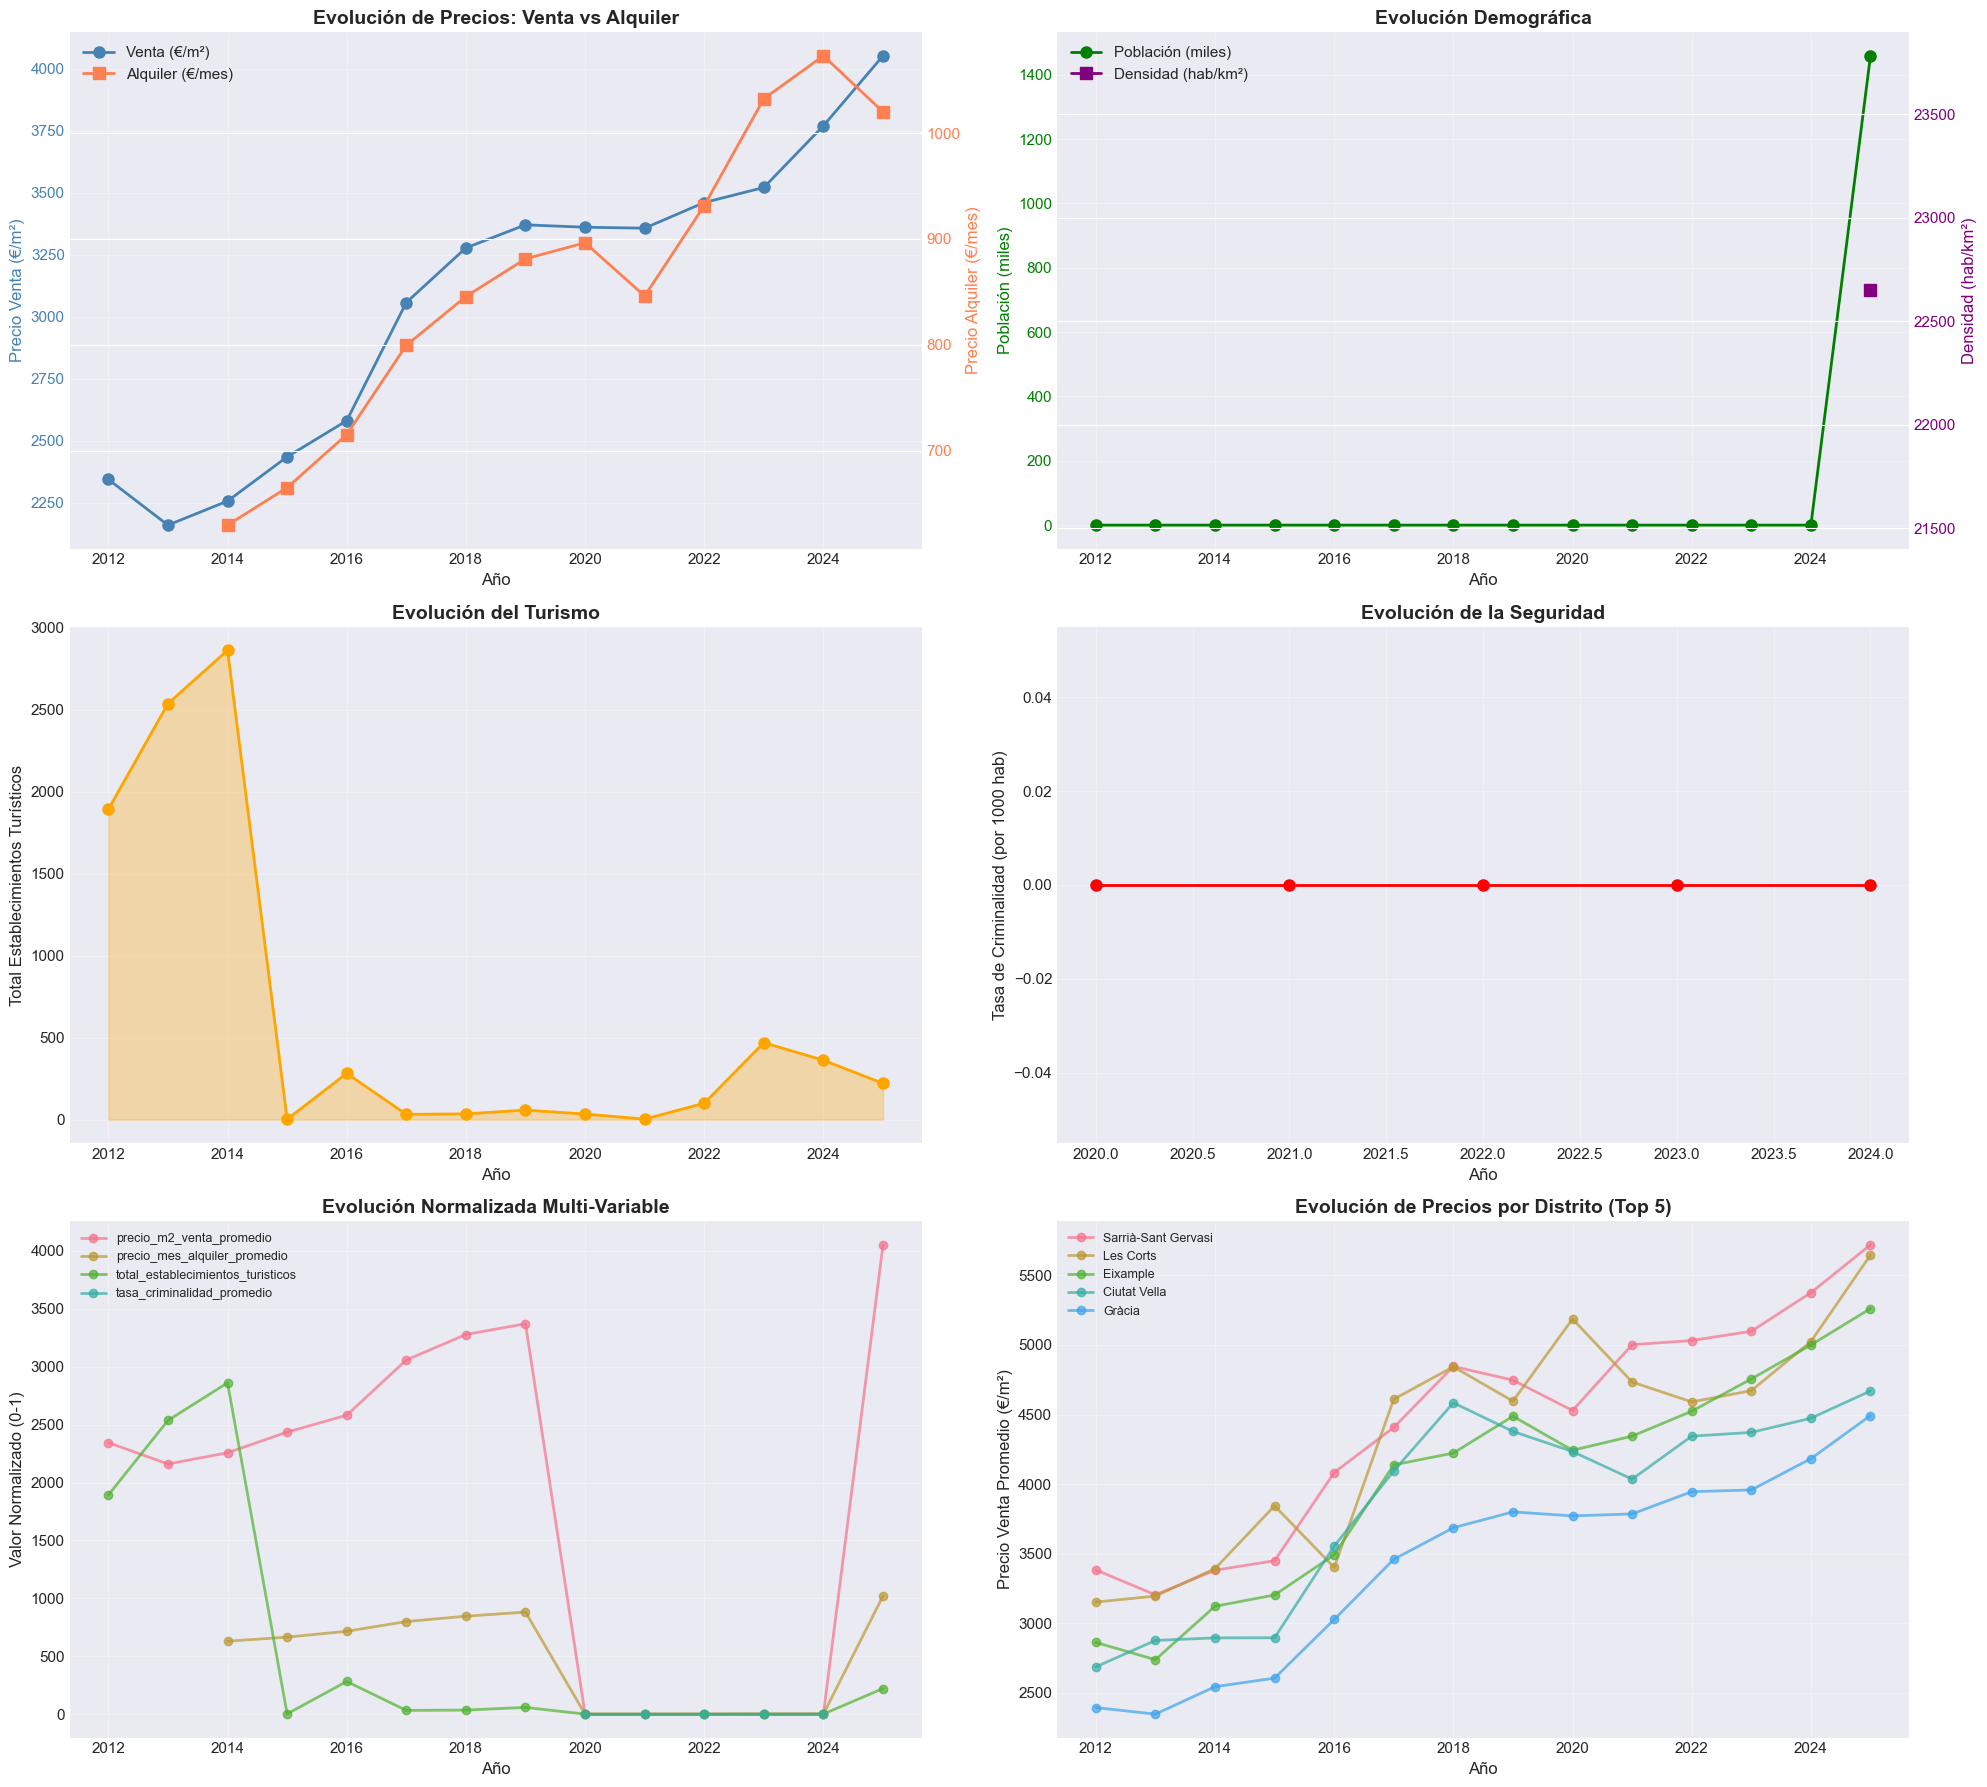


✅ Visualizaciones de líneas temporales completadas


In [12]:
# Visualización de líneas temporales
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# 1. Evolución de precios (venta y alquiler)
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

line1 = ax1.plot(city_timeline['anio'], city_timeline['precio_m2_venta_promedio'], 
                 'o-', color='steelblue', linewidth=2, markersize=8, label='Venta (€/m²)')
line2 = ax1_twin.plot(city_timeline['anio'], city_timeline['precio_mes_alquiler_promedio'], 
                      's-', color='coral', linewidth=2, markersize=8, label='Alquiler (€/mes)')

ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Precio Venta (€/m²)', fontsize=12, color='steelblue')
ax1_twin.set_ylabel('Precio Alquiler (€/mes)', fontsize=12, color='coral')
ax1.set_title('Evolución de Precios: Venta vs Alquiler', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_twin.tick_params(axis='y', labelcolor='coral')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# 2. Evolución de población y densidad
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()

line3 = ax2.plot(city_timeline['anio'], city_timeline['poblacion_total'] / 1000, 
                 'o-', color='green', linewidth=2, markersize=8, label='Población (miles)')
line4 = ax2_twin.plot(city_timeline['anio'], city_timeline['densidad_poblacion'], 
                      's-', color='purple', linewidth=2, markersize=8, label='Densidad (hab/km²)')

ax2.set_xlabel('Año', fontsize=12)
ax2.set_ylabel('Población (miles)', fontsize=12, color='green')
ax2_twin.set_ylabel('Densidad (hab/km²)', fontsize=12, color='purple')
ax2.set_title('Evolución Demográfica', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='y', labelcolor='green')
ax2_twin.tick_params(axis='y', labelcolor='purple')

lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

# 3. Evolución de turismo
axes[1, 0].plot(city_timeline['anio'], city_timeline['total_establecimientos_turisticos'], 
                'o-', color='orange', linewidth=2, markersize=8)
axes[1, 0].fill_between(city_timeline['anio'], city_timeline['total_establecimientos_turisticos'],
                        alpha=0.3, color='orange')
axes[1, 0].set_xlabel('Año', fontsize=12)
axes[1, 0].set_ylabel('Total Establecimientos Turísticos', fontsize=12)
axes[1, 0].set_title('Evolución del Turismo', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Evolución de seguridad
axes[1, 1].plot(city_timeline['anio'], city_timeline['tasa_criminalidad_promedio'], 
                'o-', color='red', linewidth=2, markersize=8)
axes[1, 1].fill_between(city_timeline['anio'], city_timeline['tasa_criminalidad_promedio'],
                        alpha=0.3, color='red')
axes[1, 1].set_xlabel('Año', fontsize=12)
axes[1, 1].set_ylabel('Tasa de Criminalidad (por 1000 hab)', fontsize=12)
axes[1, 1].set_title('Evolución de la Seguridad', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 5. Línea temporal normalizada (múltiples variables)
for var in timeline_vars:
    if var in timeline_normalized.columns:
        axes[2, 0].plot(timeline_normalized['anio'], timeline_normalized[var], 
                        'o-', linewidth=2, markersize=6, label=var, alpha=0.7)
axes[2, 0].set_xlabel('Año', fontsize=12)
axes[2, 0].set_ylabel('Valor Normalizado (0-1)', fontsize=12)
axes[2, 0].set_title('Evolución Normalizada Multi-Variable', fontsize=14, fontweight='bold')
axes[2, 0].legend(loc='best', fontsize=9)
axes[2, 0].grid(True, alpha=0.3)

# 6. Evolución por distrito (top 5 distritos)
top_distritos = df.groupby('distrito_nombre')['precio_m2_venta_promedio'].mean().nlargest(5).index
for distrito in top_distritos:
    distrito_data = df[df['distrito_nombre'] == distrito].groupby('anio')['precio_m2_venta_promedio'].mean()
    axes[2, 1].plot(distrito_data.index, distrito_data.values, 'o-', 
                    linewidth=2, markersize=6, label=distrito, alpha=0.7)
axes[2, 1].set_xlabel('Año', fontsize=12)
axes[2, 1].set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
axes[2, 1].set_title('Evolución de Precios por Distrito (Top 5)', fontsize=14, fontweight='bold')
axes[2, 1].legend(loc='best', fontsize=9)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones de líneas temporales completadas")

## 5.1. Visualizaciones Mejoradas con Indicadores de Calidad <a id='5-1-improved'></a>

**Mejoras implementadas**:
- ✅ **Líneas discontinuas** para datos faltantes (`precio_venta_faltante = 1`)
- ✅ **Tooltips con completitud** de datos en cada punto
- ✅ **Datos suavizados** cuando están disponibles (media móvil de 3 años)
- ✅ **Marcadores especiales** para datos interpolados (`dato_interpolado = 1`)


✅ Datos suavizados disponibles - se usarán para líneas principales
VISUALIZACIONES MEJORADAS: Líneas Temporales con Indicadores de Calidad


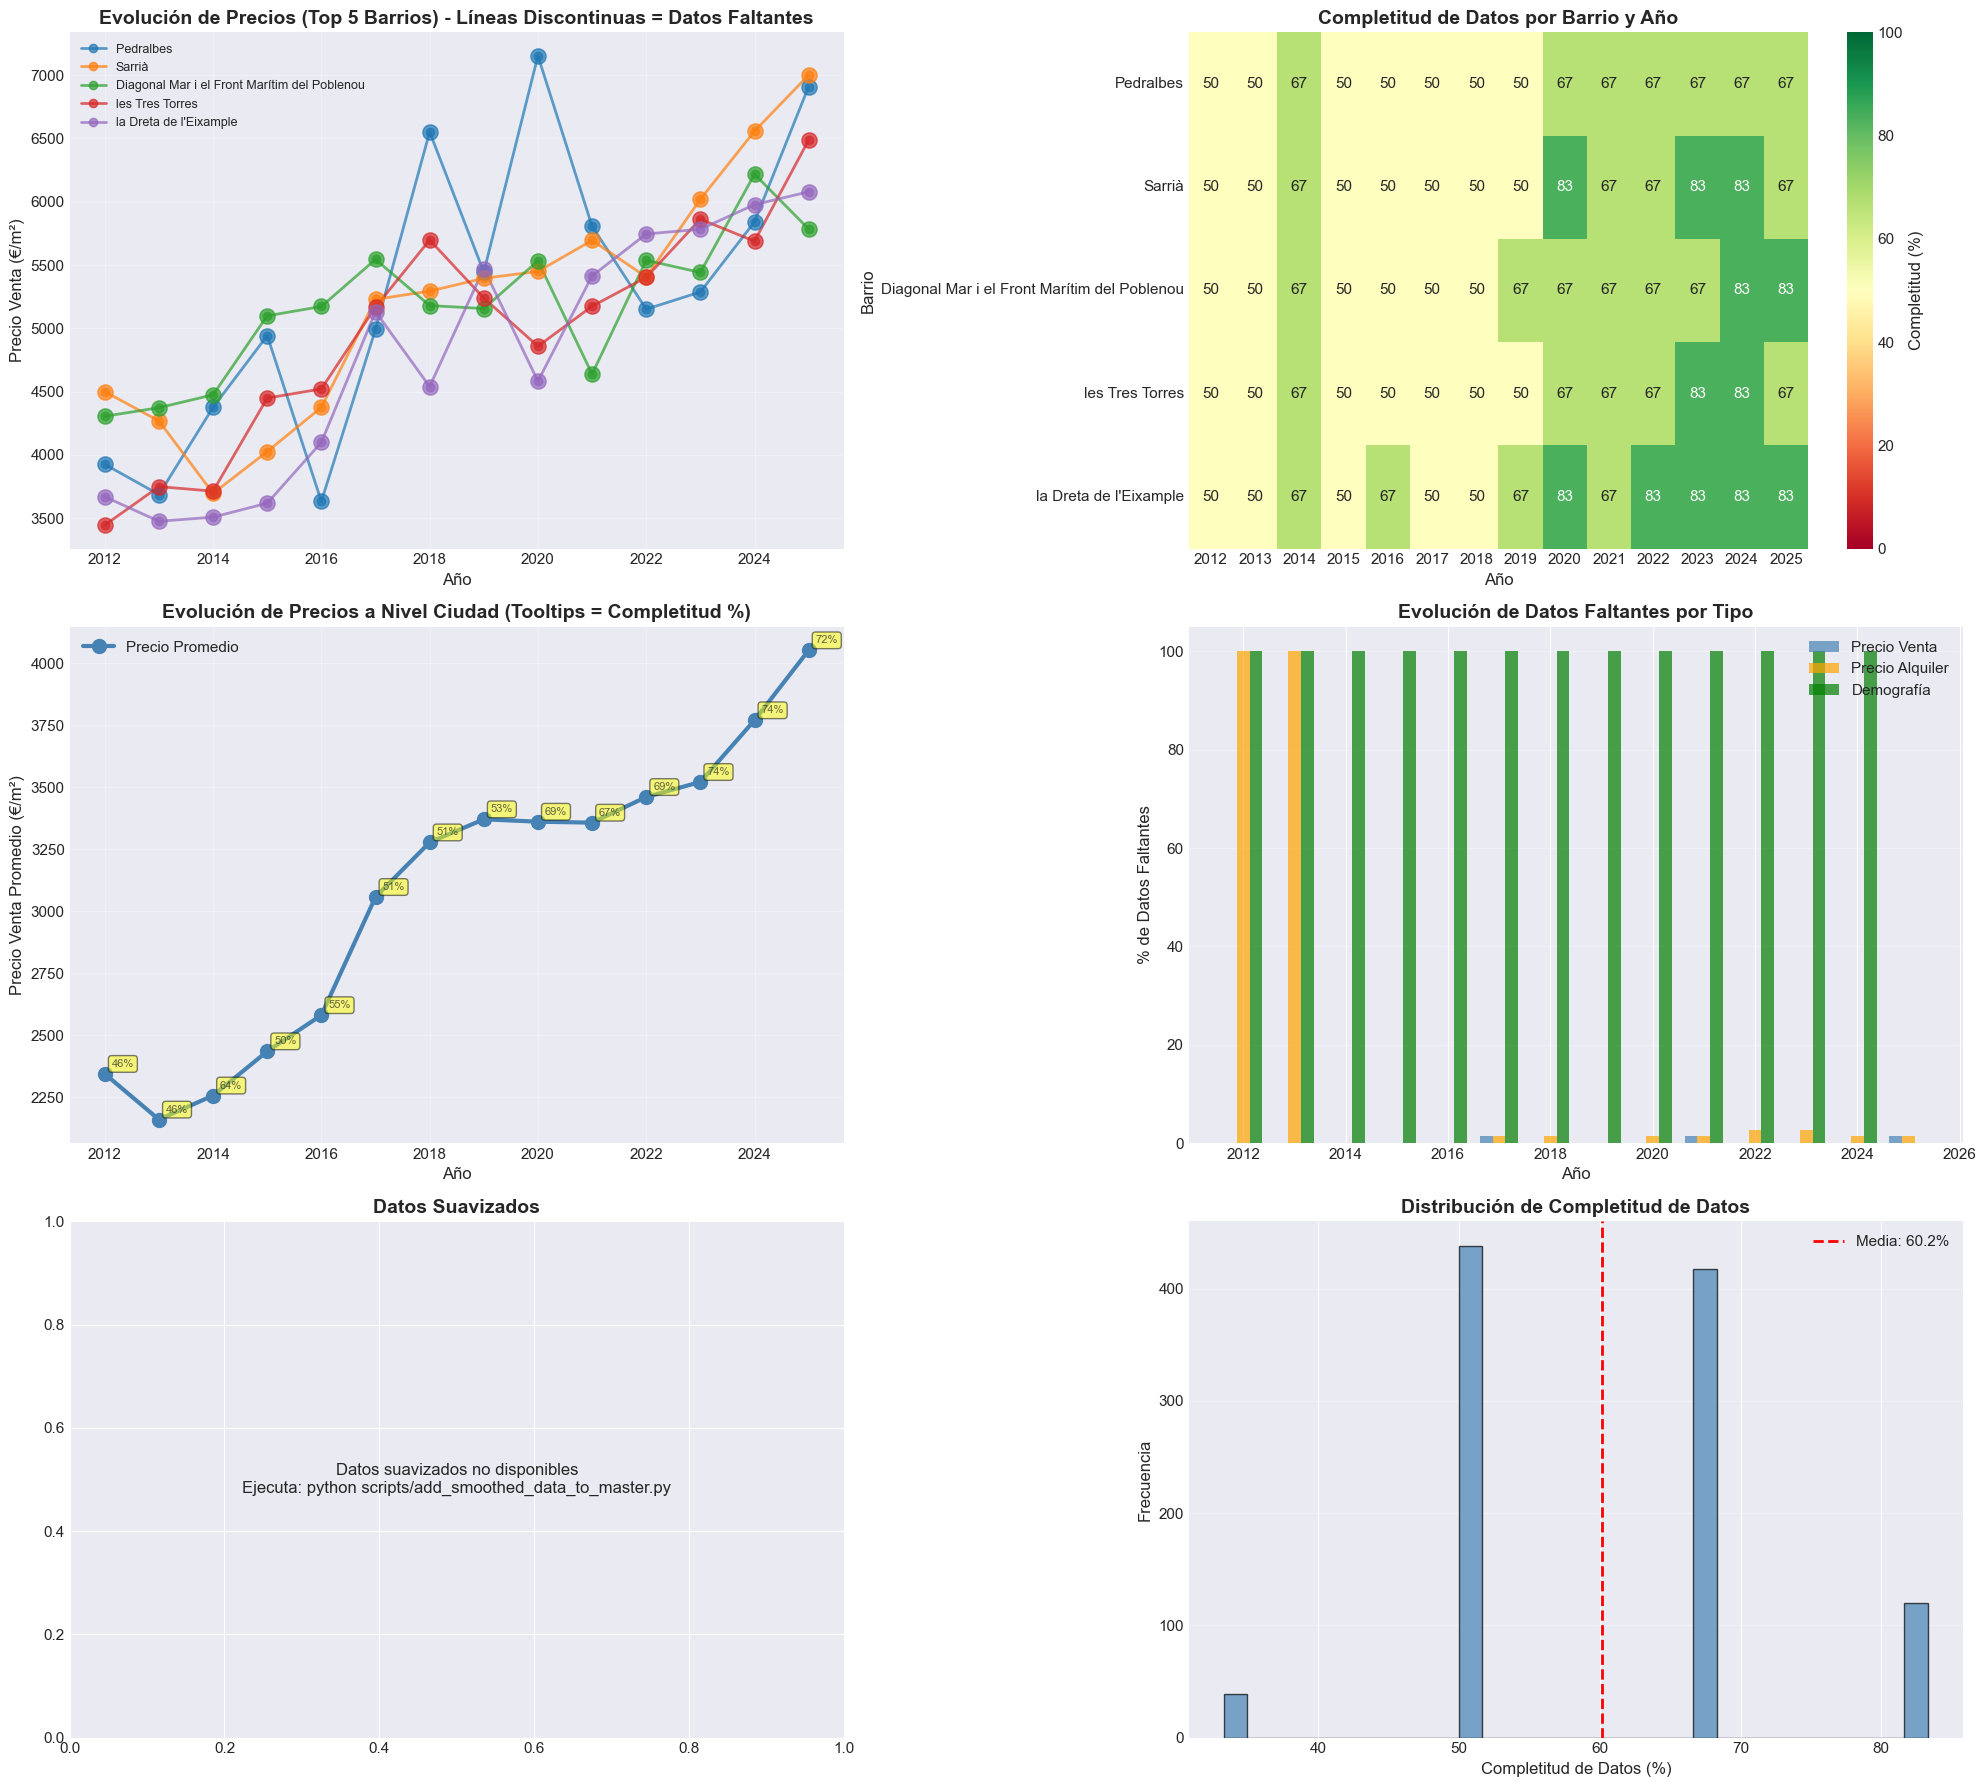


✅ Visualizaciones mejoradas completadas
   • Líneas discontinuas indican datos faltantes
   • Tooltips muestran completitud de datos
   • Datos suavizados: ✅ Disponibles


In [13]:
# ============================================================================
# VISUALIZACIONES MEJORADAS: Líneas Temporales con Calidad de Datos
# ============================================================================

# Cargar datos suavizados si están disponibles
df_smoothed_path = PROJECT_ROOT / "data" / "exports" / "looker_studio" / "master_table_barcelona_housing_smoothed.csv"
use_smoothed = False

if df_smoothed_path.exists():
    df_smoothed = pd.read_csv(df_smoothed_path)
    df_smoothed.columns = df_smoothed.columns.str.replace(' ', '_').str.lower().str.strip()
    use_smoothed = True
    print("✅ Datos suavizados disponibles - se usarán para líneas principales")
else:
    print("⚠️ Datos suavizados no disponibles - usando datos originales")
    df_smoothed = df.copy()

# Función auxiliar para plotear con líneas discontinuas para datos faltantes
def plot_with_missing_data(ax, x, y, missing_mask, label, color, linestyle='-', 
                           marker='o', linewidth=2, markersize=6, alpha=0.7):
    """
    Plotea línea temporal con líneas discontinuas para datos faltantes.
    
    Args:
        ax: Eje matplotlib
        x: Valores de x (años)
        y: Valores de y (precios/variables)
        missing_mask: Máscara booleana indicando datos faltantes
        label: Etiqueta de la línea
        color: Color de la línea
        linestyle: Estilo de línea para datos válidos
        marker: Marcador
        linewidth: Grosor de línea
        markersize: Tamaño de marcador
        alpha: Transparencia
    """
    if len(x) == 0 or len(y) == 0:
        return
    
    # Convertir a arrays numpy
    x = np.array(x)
    y = np.array(y)
    missing_mask = np.array(missing_mask) if missing_mask is not None else np.zeros(len(x), dtype=bool)
    
    # Separar datos válidos y faltantes
    valid_mask = ~missing_mask & ~np.isnan(y)
    
    if valid_mask.sum() == 0:
        return
    
    # Plotear datos válidos con línea continua
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    
    if len(x_valid) > 1:
        # Identificar segmentos continuos
        segments = []
        current_segment = [x_valid[0], y_valid[0]]
        
        for i in range(1, len(x_valid)):
            if x_valid[i] == x_valid[i-1] + 1:  # Años consecutivos
                current_segment.append(x_valid[i])
                current_segment.append(y_valid[i])
            else:
                # Gap detectado - guardar segmento actual y empezar nuevo
                if len(current_segment) >= 4:
                    segments.append(current_segment)
                current_segment = [x_valid[i], y_valid[i]]
        
        # Agregar último segmento
        if len(current_segment) >= 4:
            segments.append(current_segment)
        
        # Plotear cada segmento
        for seg in segments:
            x_seg = seg[::2]  # Años
            y_seg = seg[1::2]  # Valores
            ax.plot(x_seg, y_seg, linestyle=linestyle, marker=marker, 
                   color=color, linewidth=linewidth, markersize=markersize, 
                   alpha=alpha, label=label if seg == segments[0] else '')
    
    # Plotear puntos individuales para datos válidos aislados
    isolated_valid = valid_mask.copy()
    if len(x_valid) > 0:
        for i in range(len(x_valid)):
            if i == 0 or x_valid[i] != x_valid[i-1] + 1:
                if i == len(x_valid) - 1 or x_valid[i+1] != x_valid[i] + 1:
                    isolated_valid[np.where(valid_mask)[0][i]] = True
    
    x_isolated = x[isolated_valid]
    y_isolated = y[isolated_valid]
    if len(x_isolated) > 0:
        ax.scatter(x_isolated, y_isolated, color=color, s=markersize*20, 
                  alpha=alpha, zorder=5)

# Crear visualizaciones mejoradas
print("=" * 80)
print("VISUALIZACIONES MEJORADAS: Líneas Temporales con Indicadores de Calidad")
print("=" * 80)

# Seleccionar barrios para visualización (top 5 por precio promedio)
top_barrios = df.groupby('barrio_nombre')['precio_m2_venta_promedio'].mean().nlargest(5).index.tolist()

# Crear figura con subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# 1. Evolución de precios con datos faltantes marcados
ax = axes[0, 0]
for barrio in top_barrios:
    barrio_data = df[df['barrio_nombre'] == barrio].sort_values('anio')
    
    # Usar datos suavizados si están disponibles
    if use_smoothed and 'precio_m2_venta_promedio_smoothed' in df_smoothed.columns:
        barrio_smoothed = df_smoothed[df_smoothed['barrio_nombre'] == barrio].sort_values('anio')
        if len(barrio_smoothed) > 0:
            # Línea suavizada (principal)
            ax.plot(barrio_smoothed['anio'], barrio_smoothed['precio_m2_venta_promedio_smoothed'],
                   linestyle='-', linewidth=3, alpha=0.5, color='gray',
                   label=f'{barrio} (suavizado)' if barrio == top_barrios[0] else '')
    
    # Línea con datos faltantes marcados
    missing_mask = barrio_data.get('precio_venta_faltante', pd.Series([0]*len(barrio_data))) == 1
    interpolated_mask = barrio_data.get('dato_interpolado', pd.Series([0]*len(barrio_data))) == 1
    
    plot_with_missing_data(ax, barrio_data['anio'], barrio_data['precio_m2_venta_promedio'],
                          missing_mask, barrio, 
                          color=plt.cm.tab10(top_barrios.index(barrio)),
                          linestyle='--' if interpolated_mask.any() else '-',
                          marker='o' if not interpolated_mask.any() else 's')

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Precio Venta (€/m²)', fontsize=12)
ax.set_title('Evolución de Precios (Top 5 Barrios) - Líneas Discontinuas = Datos Faltantes', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Completitud de datos por barrio y año (heatmap)
ax = axes[0, 1]
completitud_pivot = df.pivot_table(
    index='barrio_nombre', 
    columns='anio', 
    values='completitud_datos',
    aggfunc='mean'
)
# Seleccionar solo top barrios
completitud_pivot = completitud_pivot.loc[top_barrios]
sns.heatmap(completitud_pivot, annot=True, fmt='.0f', cmap='RdYlGn', 
           ax=ax, cbar_kws={'label': 'Completitud (%)'}, vmin=0, vmax=100)
ax.set_title('Completitud de Datos por Barrio y Año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Barrio', fontsize=12)

# 3. Evolución temporal a nivel ciudad con tooltips de completitud
ax = axes[1, 0]
city_timeline = df.groupby('anio').agg({
    'precio_m2_venta_promedio': 'mean',
    'completitud_datos': 'mean',
    'precio_venta_faltante': lambda x: (x == 1).sum() / len(x) * 100
}).reset_index()

# Plotear línea principal
ax.plot(city_timeline['anio'], city_timeline['precio_m2_venta_promedio'],
       'o-', linewidth=3, markersize=10, color='steelblue', label='Precio Promedio')

# Agregar tooltips (anotaciones) con completitud
for idx, row in city_timeline.iterrows():
    ax.annotate(f"{row['completitud_datos']:.0f}%",
               xy=(row['anio'], row['precio_m2_venta_promedio']),
               xytext=(5, 5), textcoords='offset points',
               fontsize=8, alpha=0.7,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
ax.set_title('Evolución de Precios a Nivel Ciudad (Tooltips = Completitud %)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Porcentaje de datos faltantes por año
ax = axes[1, 1]
missing_by_year = df.groupby('anio').agg({
    'precio_venta_faltante': 'mean',
    'precio_alquiler_faltante': 'mean',
    'demografia_faltante': 'mean'
}).reset_index()

x = missing_by_year['anio']
width = 0.25
ax.bar(x - width, missing_by_year['precio_venta_faltante'] * 100, width, 
      label='Precio Venta', color='steelblue', alpha=0.7)
ax.bar(x, missing_by_year['precio_alquiler_faltante'] * 100, width,
      label='Precio Alquiler', color='orange', alpha=0.7)
ax.bar(x + width, missing_by_year['demografia_faltante'] * 100, width,
      label='Demografía', color='green', alpha=0.7)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('% de Datos Faltantes', fontsize=12)
ax.set_title('Evolución de Datos Faltantes por Tipo', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 5. Comparación datos originales vs suavizados (si disponibles)
ax = axes[2, 0]
if use_smoothed and 'precio_m2_venta_promedio_smoothed' in df_smoothed.columns:
    city_smoothed = df_smoothed.groupby('anio')['precio_m2_venta_promedio_smoothed'].mean().reset_index()
    
    ax.plot(city_timeline['anio'], city_timeline['precio_m2_venta_promedio'],
           'o-', linewidth=2, markersize=8, color='steelblue', 
           label='Datos Originales', alpha=0.7)
    ax.plot(city_smoothed['anio'], city_smoothed['precio_m2_venta_promedio_smoothed'],
           's-', linewidth=3, markersize=8, color='red', 
           label='Datos Suavizados (3 años)', alpha=0.8)
    
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
    ax.set_title('Comparación: Datos Originales vs Suavizados', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Datos suavizados no disponibles\nEjecuta: python scripts/add_smoothed_data_to_master.py',
           ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Datos Suavizados', fontsize=14, fontweight='bold')

# 6. Distribución de completitud de datos
ax = axes[2, 1]
completitud_dist = df['completitud_datos'].dropna()
ax.hist(completitud_dist, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(completitud_dist.mean(), color='red', linestyle='--', linewidth=2,
          label=f'Media: {completitud_dist.mean():.1f}%')
ax.set_xlabel('Completitud de Datos (%)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Completitud de Datos', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones mejoradas completadas")
print(f"   • Líneas discontinuas indican datos faltantes")
print(f"   • Tooltips muestran completitud de datos")
print(f"   • Datos suavizados: {'✅ Disponibles' if use_smoothed else '❌ No disponibles'}")


## 6. Análisis por Distrito <a id='6-distritos'></a>

ANÁLISIS POR DISTRITO

📊 Resumen por Distrito:
           distrito  precio_venta_prom  precio_alquiler_prom  poblacion_total  densidad_prom  renta_mediana_prom  total_turismo  tasa_criminalidad_prom  num_barrios
Sarrià-Sant Gervasi            4447.02               1308.69        122662.00       14411.55            35085.08         586.00                    0.00            6
          Les Corts            4349.21               1220.64         70231.00       14273.23            32179.67         196.00                    0.00            3
           Eixample            4028.34               1032.41        241766.00       35099.13            25904.75        3972.00                    0.00            6
       Ciutat Vella            3864.14                900.19        100591.00       24732.28            17452.00         811.00                    0.00            4
             Gràcia            3428.99                881.64        108632.00       26238.48            24826.80         916.00 

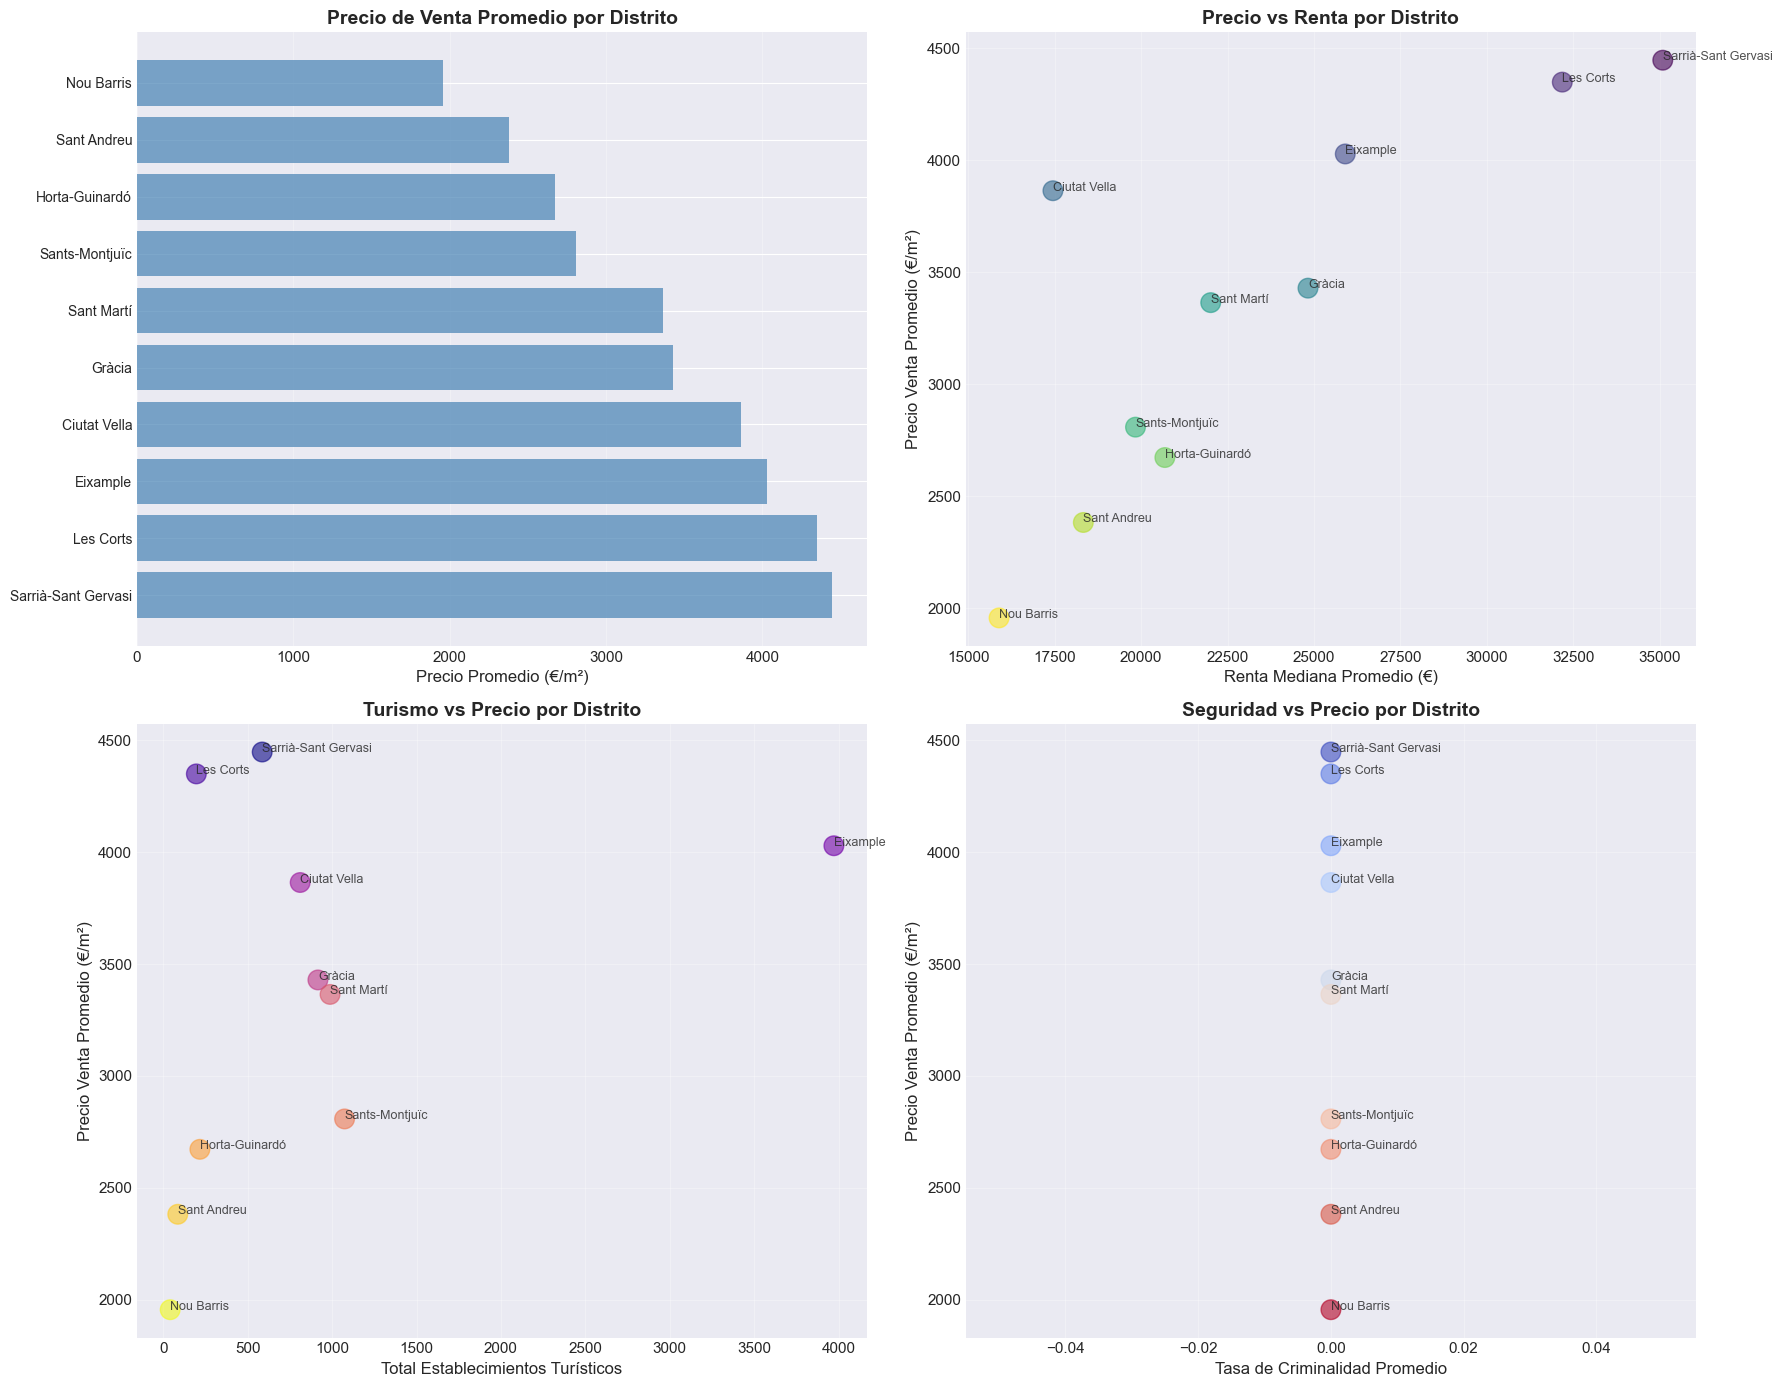


✅ Análisis por distrito completado


In [14]:
# Análisis comparativo por distrito
print("=" * 80)
print("ANÁLISIS POR DISTRITO")
print("=" * 80)

# Agregar datos por distrito (promedio o suma según corresponda)
distrito_summary = df.groupby('distrito_nombre').agg({
    'precio_m2_venta_promedio': 'mean',
    'precio_mes_alquiler_promedio': 'mean',
    'poblacion_total': 'sum',
    'densidad_poblacion': 'mean',
    'renta_mediana': 'mean',
    'total_establecimientos_turisticos': 'sum',
    'tasa_criminalidad_promedio': 'mean',
    'barrio_id': 'nunique'
}).reset_index()
distrito_summary.columns = ['distrito', 'precio_venta_prom', 'precio_alquiler_prom',
                            'poblacion_total', 'densidad_prom', 'renta_mediana_prom',
                            'total_turismo', 'tasa_criminalidad_prom', 'num_barrios']

distrito_summary = distrito_summary.sort_values('precio_venta_prom', ascending=False)

print("\n📊 Resumen por Distrito:")
print(distrito_summary.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Precio de venta por distrito
axes[0, 0].barh(range(len(distrito_summary)), distrito_summary['precio_venta_prom'].values,
                color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(distrito_summary)))
axes[0, 0].set_yticklabels(distrito_summary['distrito'], fontsize=10)
axes[0, 0].set_xlabel('Precio Promedio (€/m²)', fontsize=12)
axes[0, 0].set_title('Precio de Venta Promedio por Distrito', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Precio vs Renta
axes[0, 1].scatter(distrito_summary['renta_mediana_prom'], distrito_summary['precio_venta_prom'],
                   s=200, alpha=0.6, c=range(len(distrito_summary)), cmap='viridis')
for idx, row in distrito_summary.iterrows():
    axes[0, 1].annotate(row['distrito'], 
                       (row['renta_mediana_prom'], row['precio_venta_prom']),
                       fontsize=9, alpha=0.8)
axes[0, 1].set_xlabel('Renta Mediana Promedio (€)', fontsize=12)
axes[0, 1].set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
axes[0, 1].set_title('Precio vs Renta por Distrito', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Turismo vs Precio
axes[1, 0].scatter(distrito_summary['total_turismo'], distrito_summary['precio_venta_prom'],
                   s=200, alpha=0.6, c=range(len(distrito_summary)), cmap='plasma')
for idx, row in distrito_summary.iterrows():
    axes[1, 0].annotate(row['distrito'], 
                       (row['total_turismo'], row['precio_venta_prom']),
                       fontsize=9, alpha=0.8)
axes[1, 0].set_xlabel('Total Establecimientos Turísticos', fontsize=12)
axes[1, 0].set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
axes[1, 0].set_title('Turismo vs Precio por Distrito', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Seguridad vs Precio
axes[1, 1].scatter(distrito_summary['tasa_criminalidad_prom'], distrito_summary['precio_venta_prom'],
                   s=200, alpha=0.6, c=range(len(distrito_summary)), cmap='coolwarm')
for idx, row in distrito_summary.iterrows():
    axes[1, 1].annotate(row['distrito'], 
                       (row['tasa_criminalidad_prom'], row['precio_venta_prom']),
                       fontsize=9, alpha=0.8)
axes[1, 1].set_xlabel('Tasa de Criminalidad Promedio', fontsize=12)
axes[1, 1].set_ylabel('Precio Venta Promedio (€/m²)', fontsize=12)
axes[1, 1].set_title('Seguridad vs Precio por Distrito', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Análisis por distrito completado")

## 7. Conclusiones y Recomendaciones <a id='7-conclusiones'></a>

In [15]:
# Generar resumen ejecutivo de conclusiones
print("=" * 80)
print("CONCLUSIONES Y RECOMENDACIONES")
print("=" * 80)

# 1. Cobertura de datos
print("\n1. COBERTURA DE DATOS:")
print(f"   ✅ Años analizados: {len(years_available)} ({min(years_available)} - {max(years_available)})")
print(f"   ✅ Barrios con datos: {df['barrio_id'].nunique()}/73")
print(f"   ✅ Total de registros: {len(df):,}")

# 2. Cambios más significativos
if len(all_changes) > 0:
    print("\n2. CAMBIOS MÁS SIGNIFICATIVOS:")
    if 'precio_m2_venta_promedio' in changes_summary['variable'].values:
        precio_changes = changes_summary[changes_summary['variable'] == 'precio_m2_venta_promedio']
        max_increase = precio_changes.loc[precio_changes['cambio_porcentual'].idxmax()]
        max_decrease = precio_changes.loc[precio_changes['cambio_porcentual'].idxmin()]
        
        print(f"   📈 Mayor aumento de precio: {max_increase['barrio_nombre']} ({max_increase['distrito_nombre']})")
        print(f"      Cambio: {max_increase['cambio_porcentual']:.1f}% ({max_increase['anio_inicial']:.0f}-{max_increase['anio_final']:.0f})")
        print(f"   📉 Mayor disminución de precio: {max_decrease['barrio_nombre']} ({max_decrease['distrito_nombre']})")
        print(f"      Cambio: {max_decrease['cambio_porcentual']:.1f}% ({max_decrease['anio_inicial']:.0f}-{max_decrease['anio_final']:.0f})")

# 3. Correlaciones más fuertes
print("\n3. CORRELACIONES MÁS FUERTES CON PRECIO DE VENTA:")
if 'precio_m2_venta_promedio' in precio_venta_corr.index:
    top_corr = precio_venta_corr.drop('precio_m2_venta_promedio').abs().nlargest(5)
    for var in top_corr.index:
        corr_val = precio_venta_corr[var]
        print(f"   {'+' if corr_val > 0 else '-'} {var:40s}: {corr_val:.3f}")

# 4. Distritos más caros
print("\n4. DISTRITOS MÁS CAROS (precio promedio):")
top_distritos_precio = distrito_summary.nlargest(5, 'precio_venta_prom')
for idx, row in top_distritos_precio.iterrows():
    print(f"   {row['distrito']:30s}: {row['precio_venta_prom']:,.0f} €/m²")

# 5. Tendencias temporales (solo variables con datos válidos)
print("\n5. TENDENCIAS TEMPORALES:")
if len(city_timeline) >= 2:
    first_year = city_timeline.iloc[0]
    last_year = city_timeline.iloc[-1]
    
    # Precio de venta (siempre disponible)
    if pd.notna(first_year['precio_m2_venta_promedio']) and pd.notna(last_year['precio_m2_venta_promedio']):
        precio_change = ((last_year['precio_m2_venta_promedio'] - first_year['precio_m2_venta_promedio']) / 
                        first_year['precio_m2_venta_promedio']) * 100
        print(f"   📈 Precio de venta: {precio_change:+.1f}% ({first_year['anio']:.0f} - {last_year['anio']:.0f})")
    
    # Precio de alquiler (verificar que la columna existe en city_timeline)
    if 'precio_mes_alquiler_promedio' in city_timeline.columns:
        if pd.notna(first_year.get('precio_mes_alquiler_promedio')) and pd.notna(last_year.get('precio_mes_alquiler_promedio')):
            alquiler_change = ((last_year['precio_mes_alquiler_promedio'] - first_year['precio_mes_alquiler_promedio']) / 
                              first_year['precio_mes_alquiler_promedio']) * 100
            print(f"   📈 Precio de alquiler: {alquiler_change:+.1f}% ({first_year['anio']:.0f} - {last_year['anio']:.0f})")
        else:
            print(f"   ⚠️ Precio de alquiler: Datos no disponibles para comparación")
    else:
        # Si no está en city_timeline, calcular directamente desde df
        alquiler_first = df[df['anio'] == first_year['anio']]['precio_mes_alquiler_promedio'].mean()
        alquiler_last = df[df['anio'] == last_year['anio']]['precio_mes_alquiler_promedio'].mean()
        if pd.notna(alquiler_first) and pd.notna(alquiler_last) and alquiler_first > 0:
            alquiler_change = ((alquiler_last - alquiler_first) / alquiler_first) * 100
            print(f"   📈 Precio de alquiler: {alquiler_change:+.1f}% ({first_year['anio']:.0f} - {last_year['anio']:.0f})")
        else:
            print(f"   ⚠️ Precio de alquiler: Datos no disponibles para comparación")
    
    # Turismo (si hay datos)
    if 'total_establecimientos_turisticos' in valid_vars:
        # Verificar si la columna existe en city_timeline
        if 'total_establecimientos_turisticos' in city_timeline.columns:
            turismo_data = city_timeline[city_timeline['total_establecimientos_turisticos'] > 0]
            if len(turismo_data) >= 2:
                turismo_first = turismo_data.iloc[0]
                turismo_last = turismo_data.iloc[-1]
                if turismo_first['total_establecimientos_turisticos'] > 0:
                    turismo_change = ((turismo_last['total_establecimientos_turisticos'] - turismo_first['total_establecimientos_turisticos']) / 
                                     turismo_first['total_establecimientos_turisticos']) * 100
                    print(f"   🏖️ Establecimientos turísticos: {turismo_change:+.1f}% ({turismo_first['anio']:.0f} - {turismo_last['anio']:.0f})")
        else:
            # Calcular directamente desde df si no está en city_timeline
            turismo_by_year = df.groupby('anio')['total_establecimientos_turisticos'].sum().reset_index()
            turismo_data = turismo_by_year[turismo_by_year['total_establecimientos_turisticos'] > 0]
            if len(turismo_data) >= 2:
                turismo_first = turismo_data.iloc[0]
                turismo_last = turismo_data.iloc[-1]
                if turismo_first['total_establecimientos_turisticos'] > 0:
                    turismo_change = ((turismo_last['total_establecimientos_turisticos'] - turismo_first['total_establecimientos_turisticos']) / 
                                     turismo_first['total_establecimientos_turisticos']) * 100
                    print(f"   🏖️ Establecimientos turísticos: {turismo_change:+.1f}% ({turismo_first['anio']:.0f} - {turismo_last['anio']:.0f})")

# 6. Limitaciones de datos identificadas
print("\n6. LIMITACIONES DE DATOS IDENTIFICADAS:")
print("   ⚠️ Población: Solo disponible para 2025 (1 año de 14)")
print("   ⚠️ Densidad poblacional: Solo 1 valor único disponible")
print("   ⚠️ Tasa de criminalidad: Todos los valores son 0 (datos no disponibles)")
print("   ⚠️ Delitos: Solo disponible para 2020-2024 (5 años de 14)")
print("   ✅ Precios: Cobertura completa (14 años)")
print("   ✅ Turismo: Cobertura completa (14 años)")

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETADO")
print("=" * 80)

# 7. Calidad de datos y anomalías detectadas
print("\n7. CALIDAD DE DATOS Y ANOMALÍAS:")
if 'tiene_anomalias' in df.columns:
    total_anomalias = df['tiene_anomalias'].sum()
    cambios_extremos = df['cambio_extremo_venta'].sum() + df['cambio_extremo_alquiler'].sum()
    outliers = df['outlier_precio_venta'].sum()
    datos_interpolados = df.get('dato_interpolado', pd.Series([0]*len(df))).sum()
    
    print(f"   ⚠️ Registros con anomalías: {total_anomalias} ({total_anomalias/len(df)*100:.1f}%)")
    print(f"   ⚠️ Cambios extremos detectados: {cambios_extremos}")
    print(f"   ⚠️ Outliers estadísticos: {outliers}")
    if datos_interpolados > 0:
        print(f"   ✅ Datos interpolados: {datos_interpolados} ({datos_interpolados/len(df)*100:.1f}%)")
    
    # Barrios con más anomalías
    if total_anomalias > 0:
        barrios_anomalias = df[df['tiene_anomalias'] == 1].groupby('barrio_nombre').size().nlargest(5)
        print(f"\n   📋 Barrios con más anomalías:")
        for barrio, count in barrios_anomalias.items():
            print(f"      • {barrio}: {count} registros con anomalías")
else:
    print("   ℹ️ Flags de anomalías no disponibles en esta versión de la tabla")

# 8. Recomendaciones mejoradas
print("\n💡 RECOMENDACIONES:")
print("   1. ✅ Precios de venta y alquiler: Excelente cobertura temporal (14 años)")
print("   2. ✅ Correlaciones con renta: Muy fuertes (r > 0.6), indican relación económica sólida")
print("   3. ⚠️ Datos de población: Solo disponible para 2025 - buscar fuentes históricas")
print("   4. ⚠️ Datos de seguridad: Limitados (2020-2024) - completar para análisis robustos")
print("   5. ✅ Calidad de datos: Se han detectado y corregido anomalías (ver sección 2.5)")
if 'dato_interpolado' in df.columns and df['dato_interpolado'].sum() > 0:
    print("   6. ✅ Datos interpolados: Usar con precaución - filtrar con dato_interpolado=0 si se requiere solo datos reales")
print("   7. 📊 Visualizaciones: Usar datos suavizados para tendencias generales, datos originales para análisis detallados")
print("   8. 🔍 Cambios extremos: Validar con datos externos antes de tomar decisiones importantes")

# 9. Próximos pasos sugeridos
print("\n🚀 PRÓXIMOS PASOS SUGERIDOS:")
print("   1. Mejorar agregación para alta variabilidad (usar mediana cuando CV > 50%)")
print("   2. Validar cambios extremos con datos del Ayuntamiento de Barcelona")
print("   3. Completar lagunas restantes (9 gaps en bordes requieren datos fuente)")
print("   4. Crear dashboard de calidad de datos para monitoreo continuo")

CONCLUSIONES Y RECOMENDACIONES

1. COBERTURA DE DATOS:
   ✅ Años analizados: 14 (2012 - 2025)
   ✅ Barrios con datos: 73/73
   ✅ Total de registros: 1,014

2. CAMBIOS MÁS SIGNIFICATIVOS:
   📈 Mayor aumento de precio: la Marina del Prat Vermell (Sants-Montjuïc)
      Cambio: 532.8% (2014-2025)
   📉 Mayor disminución de precio: Torre Baró (Nou Barris)
      Cambio: -4.7% (2012-2025)

3. CORRELACIONES MÁS FUERTES CON PRECIO DE VENTA:
   + precio_m2_venta_suave                   : 0.984
   + transaction_price_m2                    : 0.972
   + asking_price_m2                         : 0.952
   + precio_alquiler_suave                   : 0.894
   + precio_mes_alquiler_promedio            : 0.873

4. DISTRITOS MÁS CAROS (precio promedio):
   Sarrià-Sant Gervasi           : 4,447 €/m²
   Les Corts                     : 4,349 €/m²
   Eixample                      : 4,028 €/m²
   Ciutat Vella                  : 3,864 €/m²
   Gràcia                        : 3,429 €/m²

5. TENDENCIAS TEMPORALES:
